In [1]:
# ============================================================
# Cell 1: Imports + module reload
# ============================================================

import re
import gc
import json
import time
import math
import warnings
import importlib
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

import config
import reporter
import workloads
import modes
import controller

importlib.reload(config)
importlib.reload(reporter)
importlib.reload(workloads)
importlib.reload(modes)
importlib.reload(controller)

from config import CONFIG, RAW_RESULTS_DIR, BENCHMARK_DATA_DIR
from reporter import generate_full_report, prepare_results
from workloads import build_runtime_workload_by_name
from modes import build_runtime_mode_by_name
from controller import route_runtime_workload

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

# Avoid reporter plot generation issues.
reporter._MATPLOTLIB_AVAILABLE = False

print("Project root:", Path.cwd())
print("RAW_RESULTS_DIR:", RAW_RESULTS_DIR)
print("BENCHMARK_DATA_DIR:", BENCHMARK_DATA_DIR)

Project root: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM
RAW_RESULTS_DIR: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw
BENCHMARK_DATA_DIR: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/benchmark_data


In [2]:
# ============================================================
# Cell 2: Experiment configuration
# ============================================================

BASELINE_MODE = "fp16_baseline"
ONLINE_CONTROLLER_MODE_NAME = "online_request_boundary_controller"

# Set this manually if you want a specific completed run.
# Otherwise the notebook picks the newest dense_final_results / dense_final_prejudge_results file.
DENSE_JSON_PATH_OVERRIDE = None

RANDOM_STATE = 42
TEST_SIZE = 0.25

# Use "random" for normal train/test split.
# Use "family_group" to hold out entire workload families.
SPLIT_POLICY = "random"

# Constraint-aware oracle thresholds.
MAX_BENCHMARK_ACCURACY_DROP_PTS = 1.5
MIN_SYNTHETIC_SIMILARITY_TO_FP16 = 0.80
MAX_SYNTHETIC_REFERENCE_ROUGE_DROP = 0.02
MAX_ENERGY_RATIO_VS_FP16 = 1.00
MAX_MEMORY_RATIO_VS_FP16 = 1.02

BENCHMARK_METRIC_MAP = {
    "mmlu_pro_eval": "mmlu_pro_accuracy_mean",
    "gsm8k_eval": "gsm8k_exact_match_accuracy_mean",
    "truthfulqa_eval": "truthfulqa_accuracy_mean",
    "gpqa_eval": "gpqa_accuracy_mean",
    "mlu_eval": "mlu_accuracy_mean",
}

BENCHMARK_LABELS = {
    "mmlu_pro_eval": "MMLU-Pro",
    "gsm8k_eval": "GSM8K",
    "truthfulqa_eval": "TruthfulQA",
    "gpqa_eval": "GPQA",
    "mlu_eval": "MLU/MMMLU",
}

SYNTHETIC_FAMILIES = {
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat",
    "memory_pressure_long_context",
}

MODEL_ORDER = [
    "Decision Tree",
    "Random Forest",
    "Logistic Regression",
    "Small MLP",
]

if DENSE_JSON_PATH_OVERRIDE is not None:
    dense_json_path = Path(DENSE_JSON_PATH_OVERRIDE)
else:
    dense_candidates = sorted(
        list(RAW_RESULTS_DIR.glob("dense_final_results_*.json"))
        + list(RAW_RESULTS_DIR.glob("dense_final_prejudge_results_*.json")),
        key=lambda p: p.stat().st_mtime,
    )

    if len(dense_candidates) == 0:
        raise FileNotFoundError(
            f"No dense_final_results_*.json or dense_final_prejudge_results_*.json files found in {RAW_RESULTS_DIR}"
        )

    dense_json_path = dense_candidates[-1]

if not dense_json_path.exists():
    raise FileNotFoundError(dense_json_path)

DENSE_STAMP = (
    dense_json_path.stem
    .replace("dense_final_prejudge_results_", "")
    .replace("dense_final_results_", "")
)

PLOT_DIR = RAW_RESULTS_DIR.parent / "plots" / f"learnable_controller_{DENSE_STAMP}"
TABLE_DIR = RAW_RESULTS_DIR.parent / "processed" / f"learnable_controller_{DENSE_STAMP}"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Using dense JSON:", dense_json_path)
print("Dense stamp:", DENSE_STAMP)
print("Plot dir:", PLOT_DIR)
print("Table dir:", TABLE_DIR)

Using dense JSON: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_prejudge_results_20260508_145059.json
Dense stamp: 20260508_145059
Plot dir: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059
Table dir: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059


In [3]:
# ============================================================
# Cell 3: Locate dense benchmark results
# ============================================================

def find_latest_dense_json(raw_dir: Path):
    candidates = []
    candidates.extend(raw_dir.glob("dense_final_results_*.json"))
    candidates.extend(raw_dir.glob("dense_final_prejudge_results_*.json"))

    # Only use partials if no completed/prejudge file exists.
    if not candidates:
        candidates.extend(raw_dir.glob("dense_final_partial_*.json"))

    candidates = [
        p for p in candidates
        if p.exists()
        and "plus_online_controller" not in p.name
        and "online_controller" not in p.name
    ]

    if not candidates:
        return None

    return sorted(candidates, key=lambda p: p.stat().st_mtime)[-1]


if DENSE_JSON_PATH_OVERRIDE is not None:
    dense_json_path = Path(DENSE_JSON_PATH_OVERRIDE)
else:
    dense_json_path = find_latest_dense_json(RAW_RESULTS_DIR)

if dense_json_path is None or not dense_json_path.exists():
    raise FileNotFoundError("Could not find a dense final JSON file.")

dense_stamp = (
    dense_json_path.stem
    .replace("dense_final_results_", "")
    .replace("dense_final_prejudge_results_", "")
    .replace("dense_final_partial_", "")
)

dense_report_dir = RAW_RESULTS_DIR / f"dense_final_report_{dense_stamp}"

print("Using dense JSON:", dense_json_path)
print("Dense stamp:", dense_stamp)
print("Dense report dir:", dense_report_dir)

Using dense JSON: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_prejudge_results_20260508_145059.json
Dense stamp: 20260508_145059
Dense report dir: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_report_20260508_145059


In [4]:
# ============================================================
# Cell 4: Generate/load reporter bundle
# ============================================================

if not (dense_report_dir / "aggregated.csv").exists():
    print("Reporter bundle missing. Generating now...")
    dense_report_dir = Path(generate_full_report(
        input_path=dense_json_path,
        output_dir=dense_report_dir,
        quality_metric="auto",
    ))
else:
    print("Using existing reporter bundle.")

with open(dense_json_path, "r", encoding="utf-8") as f:
    dense_raw_rows = json.load(f)

dense_agg_df = pd.read_csv(dense_report_dir / "aggregated.csv")
dense_failure_df = pd.read_csv(dense_report_dir / "failure_summary.csv")

print("Raw rows:", len(dense_raw_rows))
print("Aggregated rows:", len(dense_agg_df))
print("Failure rows:", len(dense_failure_df))

display(dense_agg_df.head())

Using existing reporter bundle.
Raw rows: 26500
Aggregated rows: 4825
Failure rows: 4825


,mode_name,workload_name,workload_cell,system_condition,backend,benchmark_suite,benchmark_subset,benchmark_language,evaluation_mode,benchmark_primary_metric_name,...,mt_bench_score_median,mt_bench_score_p95,mt_bench_score_min,mt_bench_score_max,alpacaeval2_lc_win_rate_mean,alpacaeval2_lc_win_rate_std,alpacaeval2_lc_win_rate_median,alpacaeval2_lc_win_rate_p95,alpacaeval2_lc_win_rate_min,alpacaeval2_lc_win_rate_max
0,fp16_baseline,gpqa_eval,LS,baseline,vllm,gpqa,gpqa_diamond:Chemistry:Chemistry (general),en,multiple_choice_accuracy,gpqa_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gptq_4bit,gpqa_eval,LS,baseline,vllm,gpqa,gpqa_diamond:Chemistry:Chemistry (general),en,multiple_choice_accuracy,gpqa_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,int8_quant,gpqa_eval,LS,baseline,vllm,gpqa,gpqa_diamond:Chemistry:Chemistry (general),en,multiple_choice_accuracy,gpqa_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,prefix_caching,gpqa_eval,LS,baseline,vllm,gpqa,gpqa_diamond:Chemistry:Chemistry (general),en,multiple_choice_accuracy,gpqa_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,speculative_decoding,gpqa_eval,LS,baseline,vllm,gpqa,gpqa_diamond:Chemistry:Chemistry (general),en,multiple_choice_accuracy,gpqa_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ============================================================
# Cell 5: Helper functions
# ============================================================

def canonical_workload_family_name(name):
    """
    Collapse sidecar examples and synthetic variants to workload family.

    Examples:
    mmlu_pro_eval__q0001 -> mmlu_pro_eval
    shared_prefix_chat_v17 -> shared_prefix_chat
    """
    name = str(name)

    if "__" in name:
        name = name.split("__", 1)[0]

    name = re.sub(r"_v\d+$", "", name)

    return name


def workload_key_from_raw_row(row):
    """
    Match reporter aggregation:
    benchmark examples collapse to parent benchmark,
    synthetic variants remain expanded.
    """
    name = str(row.get("workload_name"))

    if "__" in name:
        return name.split("__", 1)[0]

    return name


def is_benchmark_family(workload_family):
    return workload_family in BENCHMARK_METRIC_MAP


def first_valid(series, default=None):
    for value in series:
        if pd.notna(value):
            return value
    return default


def safe_float(value, default=np.nan):
    try:
        if value is None or pd.isna(value):
            return default
        return float(value)
    except Exception:
        return default


def safe_bool(value):
    if isinstance(value, bool):
        return value
    if pd.isna(value):
        return False
    if isinstance(value, str):
        return value.lower() in {"true", "1", "yes"}
    return bool(value)


def infer_default_prompt_tokens(workload_family):
    if workload_family.startswith("short_prompt"):
        return 128
    if workload_family.startswith("long_prompt"):
        return 1024
    if workload_family == "shared_prefix_chat":
        return 1024
    if workload_family == "memory_pressure_long_context":
        return 2048
    if workload_family in BENCHMARK_METRIC_MAP:
        return 512
    return 512


def infer_default_output_tokens(workload_family):
    if workload_family.endswith("short_output"):
        return 32
    if workload_family.endswith("long_output"):
        return 128
    if workload_family == "shared_prefix_chat":
        return 64
    if workload_family == "memory_pressure_long_context":
        return 128
    if workload_family == "gsm8k_eval":
        return 384
    if workload_family in BENCHMARK_METRIC_MAP:
        return 8
    return 64


def infer_benchmark_family(workload_family):
    if workload_family in BENCHMARK_METRIC_MAP:
        return workload_family.replace("_eval", "")
    return "synthetic"


def infer_evaluation_mode(workload_family, raw_value=None):
    if pd.notna(raw_value):
        return str(raw_value)
    if workload_family in BENCHMARK_METRIC_MAP:
        return "automatic_benchmark"
    return "synthetic_generation"


def save_table(df, name):
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path

In [6]:
# ============================================================
# Cell 6: Build mode-independent request feature table
# ============================================================

prepared_rows = prepare_results(dense_raw_rows)
raw_df = pd.DataFrame(prepared_rows)

raw_df = raw_df[
    raw_df["mode_name"].notna()
    & (raw_df["mode_name"] != ONLINE_CONTROLLER_MODE_NAME)
].copy()

raw_df["workload_key"] = raw_df.apply(workload_key_from_raw_row, axis=1)
raw_df["workload_family"] = raw_df["workload_key"].apply(canonical_workload_family_name)

feature_rows = []

for workload_key, group in raw_df.groupby("workload_key"):
    workload_family = canonical_workload_family_name(workload_key)

    prompt_tokens = safe_float(
        pd.to_numeric(group.get("prompt_tokens_target"), errors="coerce").median()
        if "prompt_tokens_target" in group.columns else np.nan,
        default=np.nan,
    )

    expected_output_tokens = safe_float(
        pd.to_numeric(group.get("max_new_tokens"), errors="coerce").median()
        if "max_new_tokens" in group.columns else np.nan,
        default=np.nan,
    )

    if pd.isna(prompt_tokens):
        prompt_tokens = infer_default_prompt_tokens(workload_family)

    if pd.isna(expected_output_tokens):
        expected_output_tokens = infer_default_output_tokens(workload_family)

    num_requests_in_batch = safe_float(
        pd.to_numeric(group.get("num_requests_in_batch"), errors="coerce").median()
        if "num_requests_in_batch" in group.columns else np.nan,
        default=1.0,
    )

    shared_prefix = (
        bool(group.get("repeated_prefix", pd.Series([False])).apply(safe_bool).any())
        or workload_family == "shared_prefix_chat"
    )

    memory_pressure = (
        bool(group.get("memory_pressure", pd.Series([False])).apply(safe_bool).any())
        or workload_family == "memory_pressure_long_context"
    )

    batch_pressure = "batched" if num_requests_in_batch > 1 else "normal"

    evaluation_mode_raw = first_valid(group.get("evaluation_mode", pd.Series(dtype=object)), default=None)

    output_prompt_ratio = expected_output_tokens / max(prompt_tokens, 1.0)

    feature_rows.append({
        "workload_key": workload_key,
        "workload_family": workload_family,

        # Version A static numeric features.
        "prompt_tokens": float(prompt_tokens),
        "expected_output_tokens": float(expected_output_tokens),
        "output_prompt_ratio": float(output_prompt_ratio),
        "log_prompt_tokens": float(np.log1p(prompt_tokens)),
        "log_expected_output_tokens": float(np.log1p(expected_output_tokens)),
        "num_requests_in_batch": float(num_requests_in_batch),
        "shared_prefix_int": int(shared_prefix),
        "memory_pressure_int": int(memory_pressure),

        # Version A static categorical features.
        "shared_prefix": str(bool(shared_prefix)),
        "memory_pressure": str(bool(memory_pressure)),
        "batch_pressure": batch_pressure,
        "evaluation_mode": infer_evaluation_mode(workload_family, evaluation_mode_raw),
        "benchmark_family": infer_benchmark_family(workload_family),

        # Version B extra feature.
        "workload_tag": workload_family,
    })

feature_df = pd.DataFrame(feature_rows).sort_values("workload_key").reset_index(drop=True)

print("Feature rows:", len(feature_df))
display(feature_df.head(20))
save_table(feature_df, "request_feature_table.csv")

Feature rows: 605


,workload_key,workload_family,prompt_tokens,expected_output_tokens,output_prompt_ratio,log_prompt_tokens,log_expected_output_tokens,num_requests_in_batch,shared_prefix_int,memory_pressure_int,shared_prefix,memory_pressure,batch_pressure,evaluation_mode,benchmark_family,workload_tag
0,gpqa_eval,gpqa_eval,512.0,8.0,0.015625,6.240276,2.197225,1.0,0,0,False,False,normal,multiple_choice_accuracy,gpqa,gpqa_eval
1,gsm8k_eval,gsm8k_eval,512.0,384.0,0.750000,6.240276,5.953243,1.0,0,0,False,False,normal,final_answer_exact_match,gsm8k,gsm8k_eval
2,long_prompt_long_output_v0,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,False,False,normal,synthetic_generation,synthetic,long_prompt_long_output
3,long_prompt_long_output_v1,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,False,False,normal,synthetic_generation,synthetic,long_prompt_long_output
4,long_prompt_long_output_v10,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,False,False,normal,synthetic_generation,synthetic,long_prompt_long_output
5,long_prompt_long_output_v11,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,False,False,normal,synthetic_generation,synthetic,long_prompt_long_output
6,long_prompt_long_output_v12,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,False,False,normal,synthetic_generation,synthetic,long_prompt_long_output
7,long_prompt_long_output_v13,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,False,False,normal,synthetic_generation,synthetic,long_prompt_long_output
8,long_prompt_long_output_v14,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,False,False,normal,synthetic_generation,synthetic,long_prompt_long_output
9,long_prompt_long_output_v15,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,False,False,normal,synthetic_generation,synthetic,long_prompt_long_output


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/request_feature_table.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/request_feature_table.csv')

In [7]:
# ============================================================
# Cell 7: Collapse aggregate metrics to one row per workload/mode
# ============================================================

agg_df = dense_agg_df.copy()

# Remove online/controller rows if a combined report accidentally got loaded.
agg_df = agg_df[
    agg_df["mode_name"].notna()
    & (agg_df["mode_name"] != ONLINE_CONTROLLER_MODE_NAME)
].copy()

agg_df["workload_key"] = agg_df["workload_name"].astype(str)

numeric_cols = agg_df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [
    c for c in agg_df.columns
    if c not in numeric_cols and c not in ["workload_key", "mode_name"]
]

agg_map = {c: "mean" for c in numeric_cols}
for c in non_numeric_cols:
    agg_map[c] = "first"

perf_df = (
    agg_df
    .groupby(["workload_key", "mode_name"], as_index=False)
    .agg(agg_map)
)

perf_df["workload_family"] = perf_df["workload_key"].apply(canonical_workload_family_name)

print("Performance rows:", len(perf_df))
print("Workloads:", perf_df["workload_key"].nunique())
print("Modes:", perf_df["mode_name"].nunique())

display(perf_df[["workload_key", "workload_family", "mode_name", "total_latency_ms_mean", "energy_per_token_j_mean"]].head(20))
save_table(perf_df, "mode_performance_table.csv")

Performance rows: 4825
Workloads: 605
Modes: 8


,workload_key,workload_family,mode_name,total_latency_ms_mean,energy_per_token_j_mean
0,gpqa_eval,gpqa_eval,fp16_baseline,53.434910,8.612962
1,gpqa_eval,gpqa_eval,gptq_4bit,61.726297,9.071237
2,gpqa_eval,gpqa_eval,int8_quant,47.081414,6.834047
3,gpqa_eval,gpqa_eval,prefix_caching,58.631842,9.047223
4,gpqa_eval,gpqa_eval,speculative_decoding,77.626107,8.687876
5,gsm8k_eval,gsm8k_eval,fp16_baseline,3149.641846,3.628337
6,gsm8k_eval,gsm8k_eval,gptq_4bit,1098.567108,1.404647
7,gsm8k_eval,gsm8k_eval,int8_quant,1641.224315,1.932411
8,gsm8k_eval,gsm8k_eval,prefix_caching,2360.263406,3.271948
9,gsm8k_eval,gsm8k_eval,speculative_decoding,1251.399517,1.496200


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/mode_performance_table.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/mode_performance_table.csv')

In [8]:
# ============================================================
# Cell 8: Build constraint-aware oracle labels
# ============================================================

def build_constraint_aware_oracle(perf_df):
    oracle_rows = []
    candidate_rows = []

    for workload_key, candidates in perf_df.groupby("workload_key"):
        candidates = candidates.copy()
        workload_family = canonical_workload_family_name(workload_key)

        fp16_rows = candidates[candidates["mode_name"] == BASELINE_MODE]
        if len(fp16_rows) == 0:
            continue

        fp16 = fp16_rows.iloc[0]

        fp16_latency = safe_float(fp16.get("total_latency_ms_mean"))
        fp16_tps = safe_float(fp16.get("tokens_per_second_mean"))
        fp16_energy = safe_float(fp16.get("energy_per_token_j_mean"))
        fp16_memory = safe_float(fp16.get("peak_gpu_memory_mb_mean"))

        candidates["latency_speedup_vs_fp16"] = fp16_latency / candidates["total_latency_ms_mean"]
        candidates["throughput_ratio_vs_fp16"] = candidates["tokens_per_second_mean"] / fp16_tps
        candidates["energy_ratio_vs_fp16"] = candidates["energy_per_token_j_mean"] / fp16_energy
        candidates["memory_ratio_vs_fp16"] = candidates["peak_gpu_memory_mb_mean"] / fp16_memory

        candidates["energy_safe"] = candidates["energy_ratio_vs_fp16"] <= MAX_ENERGY_RATIO_VS_FP16
        candidates["memory_safe"] = candidates["memory_ratio_vs_fp16"] <= MAX_MEMORY_RATIO_VS_FP16

        quality_type = "unknown"
        candidates["quality_value"] = np.nan
        candidates["quality_delta_vs_fp16"] = np.nan
        candidates["quality_safe"] = False

        # Benchmark quality: accuracy must stay within threshold of FP16.
        if workload_family in BENCHMARK_METRIC_MAP:
            metric_col = BENCHMARK_METRIC_MAP[workload_family]
            quality_type = "benchmark_accuracy"

            if metric_col in candidates.columns and pd.notna(fp16.get(metric_col)):
                fp16_quality_pct = 100.0 * safe_float(fp16.get(metric_col))

                candidates["quality_value"] = 100.0 * pd.to_numeric(candidates[metric_col], errors="coerce")
                candidates["quality_delta_vs_fp16"] = candidates["quality_value"] - fp16_quality_pct
                candidates["quality_safe"] = candidates["quality_delta_vs_fp16"] >= -MAX_BENCHMARK_ACCURACY_DROP_PTS

            elif "benchmark_primary_metric_value_mean" in candidates.columns and pd.notna(fp16.get("benchmark_primary_metric_value_mean")):
                fp16_quality_pct = 100.0 * safe_float(fp16.get("benchmark_primary_metric_value_mean"))

                candidates["quality_value"] = 100.0 * pd.to_numeric(
                    candidates["benchmark_primary_metric_value_mean"],
                    errors="coerce",
                )
                candidates["quality_delta_vs_fp16"] = candidates["quality_value"] - fp16_quality_pct
                candidates["quality_safe"] = candidates["quality_delta_vs_fp16"] >= -MAX_BENCHMARK_ACCURACY_DROP_PTS

        # Synthetic quality: use baseline similarity or reference ROUGE if available.
        else:
            quality_type = "synthetic_proxy"

            sim_col = "baseline_similarity_rouge_l_f1_mean"
            ref_col = "reference_rouge_l_f1_mean"

            has_sim = sim_col in candidates.columns and candidates[sim_col].notna().any()
            has_ref = ref_col in candidates.columns and pd.notna(fp16.get(ref_col))

            if has_sim:
                candidates["similarity_to_fp16"] = pd.to_numeric(candidates[sim_col], errors="coerce")
            else:
                candidates["similarity_to_fp16"] = np.nan

            if has_ref:
                fp16_ref = safe_float(fp16.get(ref_col))
                candidates["reference_rouge_delta_vs_fp16"] = (
                    pd.to_numeric(candidates[ref_col], errors="coerce") - fp16_ref
                )
            else:
                candidates["reference_rouge_delta_vs_fp16"] = np.nan

            if has_sim and has_ref:
                candidates["quality_value"] = candidates["similarity_to_fp16"]
                candidates["quality_delta_vs_fp16"] = candidates["reference_rouge_delta_vs_fp16"]
                candidates["quality_safe"] = (
                    (candidates["similarity_to_fp16"] >= MIN_SYNTHETIC_SIMILARITY_TO_FP16)
                    &
                    (candidates["reference_rouge_delta_vs_fp16"] >= -MAX_SYNTHETIC_REFERENCE_ROUGE_DROP)
                )
            elif has_sim:
                candidates["quality_value"] = candidates["similarity_to_fp16"]
                candidates["quality_safe"] = (
                    candidates["similarity_to_fp16"] >= MIN_SYNTHETIC_SIMILARITY_TO_FP16
                )
            elif has_ref:
                candidates["quality_value"] = pd.to_numeric(candidates[ref_col], errors="coerce")
                candidates["quality_delta_vs_fp16"] = candidates["reference_rouge_delta_vs_fp16"]
                candidates["quality_safe"] = (
                    candidates["reference_rouge_delta_vs_fp16"] >= -MAX_SYNTHETIC_REFERENCE_ROUGE_DROP
                )
            else:
                # Conservative fallback: only FP16 is quality-safe if no quality signal exists.
                candidates["quality_safe"] = candidates["mode_name"].eq(BASELINE_MODE)

        # FP16 should always be safe relative to itself.
        candidates.loc[candidates["mode_name"] == BASELINE_MODE, ["energy_safe", "memory_safe", "quality_safe"]] = True

        candidates["constraint_safe"] = (
            candidates["energy_safe"]
            & candidates["memory_safe"]
            & candidates["quality_safe"]
            & candidates["total_latency_ms_mean"].notna()
        )

        safe_candidates = candidates[candidates["constraint_safe"]].copy()

        if len(safe_candidates) == 0:
            safe_candidates = candidates[candidates["mode_name"] == BASELINE_MODE].copy()

        oracle = safe_candidates.sort_values("total_latency_ms_mean", ascending=True).iloc[0]

        oracle_rows.append({
            "workload_key": workload_key,
            "workload_family": workload_family,
            "quality_type": quality_type,
            "oracle_mode": oracle["mode_name"],
            "oracle_latency_ms": oracle["total_latency_ms_mean"],
            "oracle_energy_per_token_j": oracle["energy_per_token_j_mean"],
            "oracle_speedup_vs_fp16": oracle["latency_speedup_vs_fp16"],
            "oracle_energy_ratio_vs_fp16": oracle["energy_ratio_vs_fp16"],
            "num_candidate_modes": len(candidates),
            "num_constraint_safe_modes": int(candidates["constraint_safe"].sum()),
        })

        candidates["workload_key"] = workload_key
        candidates["workload_family"] = workload_family
        candidates["quality_type"] = quality_type
        candidate_rows.append(candidates)

    oracle_df = pd.DataFrame(oracle_rows)
    candidate_safety_df = pd.concat(candidate_rows, ignore_index=True) if candidate_rows else pd.DataFrame()

    return oracle_df, candidate_safety_df


oracle_df, candidate_safety_df = build_constraint_aware_oracle(perf_df)

print("Oracle rows:", len(oracle_df))
print("Candidate safety rows:", len(candidate_safety_df))

display(oracle_df.head(20))
display(
    oracle_df["oracle_mode"]
    .value_counts()
    .rename_axis("oracle_mode")
    .reset_index(name="count")
)

save_table(oracle_df, "constraint_aware_oracle_labels.csv")
save_table(candidate_safety_df, "candidate_safety_table.csv")

Oracle rows: 605
Candidate safety rows: 4825


,workload_key,workload_family,quality_type,oracle_mode,oracle_latency_ms,oracle_energy_per_token_j,oracle_speedup_vs_fp16,oracle_energy_ratio_vs_fp16,num_candidate_modes,num_constraint_safe_modes
0,gpqa_eval,gpqa_eval,benchmark_accuracy,fp16_baseline,53.434910,8.612962,1.000000,1.000000,5,1
1,gsm8k_eval,gsm8k_eval,benchmark_accuracy,speculative_decoding,1251.399517,1.496200,2.516896,0.412365,5,4
2,long_prompt_long_output_v0,long_prompt_long_output,synthetic_proxy,gptq_4bit,1020.801211,1.732113,2.557701,0.432779,8,8
3,long_prompt_long_output_v1,long_prompt_long_output,synthetic_proxy,gptq_4bit,1013.232903,1.794426,2.566919,0.447372,8,8
4,long_prompt_long_output_v10,long_prompt_long_output,synthetic_proxy,gptq_4bit,1021.035581,1.732732,2.537917,0.431337,8,7
5,long_prompt_long_output_v11,long_prompt_long_output,synthetic_proxy,gptq_4bit,1013.895885,1.777271,2.548906,0.446761,8,8
6,long_prompt_long_output_v12,long_prompt_long_output,synthetic_proxy,gptq_4bit,1013.459461,1.763972,2.585961,0.436516,8,8
7,long_prompt_long_output_v13,long_prompt_long_output,synthetic_proxy,gptq_4bit,1013.697971,1.793910,2.578666,0.450060,8,8
8,long_prompt_long_output_v14,long_prompt_long_output,synthetic_proxy,gptq_4bit,1013.294326,1.769046,2.570371,0.441700,8,8
9,long_prompt_long_output_v15,long_prompt_long_output,synthetic_proxy,gptq_4bit,1020.209695,1.687166,2.551077,0.423403,8,7


,oracle_mode,count
0,gptq_4bit,302
1,gptq_plus_prefix_caching,202
2,speculative_decoding,54
3,int8_quant,46
4,fp16_baseline,1


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/constraint_aware_oracle_labels.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/candidate_safety_table.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/candidate_safety_table.csv')

In [9]:
# ============================================================
# Cell 9: Build ML dataset
# ============================================================

dataset_df = (
    feature_df
    .merge(oracle_df, on=["workload_key", "workload_family"], how="inner")
    .sort_values("workload_key")
    .reset_index(drop=True)
)

print("Dataset rows:", len(dataset_df))
print("Oracle classes:", dataset_df["oracle_mode"].nunique())

display(dataset_df.head(20))
display(
    dataset_df["oracle_mode"]
    .value_counts()
    .rename_axis("oracle_mode")
    .reset_index(name="count")
)

save_table(dataset_df, "learnable_controller_dataset.csv")

Dataset rows: 605
Oracle classes: 5


,workload_key,workload_family,prompt_tokens,expected_output_tokens,output_prompt_ratio,log_prompt_tokens,log_expected_output_tokens,num_requests_in_batch,shared_prefix_int,memory_pressure_int,...,benchmark_family,workload_tag,quality_type,oracle_mode,oracle_latency_ms,oracle_energy_per_token_j,oracle_speedup_vs_fp16,oracle_energy_ratio_vs_fp16,num_candidate_modes,num_constraint_safe_modes
0,gpqa_eval,gpqa_eval,512.0,8.0,0.015625,6.240276,2.197225,1.0,0,0,...,gpqa,gpqa_eval,benchmark_accuracy,fp16_baseline,53.434910,8.612962,1.000000,1.000000,5,1
1,gsm8k_eval,gsm8k_eval,512.0,384.0,0.750000,6.240276,5.953243,1.0,0,0,...,gsm8k,gsm8k_eval,benchmark_accuracy,speculative_decoding,1251.399517,1.496200,2.516896,0.412365,5,4
2,long_prompt_long_output_v0,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,...,synthetic,long_prompt_long_output,synthetic_proxy,gptq_4bit,1020.801211,1.732113,2.557701,0.432779,8,8
3,long_prompt_long_output_v1,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,...,synthetic,long_prompt_long_output,synthetic_proxy,gptq_4bit,1013.232903,1.794426,2.566919,0.447372,8,8
4,long_prompt_long_output_v10,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,...,synthetic,long_prompt_long_output,synthetic_proxy,gptq_4bit,1021.035581,1.732732,2.537917,0.431337,8,7
5,long_prompt_long_output_v11,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,...,synthetic,long_prompt_long_output,synthetic_proxy,gptq_4bit,1013.895885,1.777271,2.548906,0.446761,8,8
6,long_prompt_long_output_v12,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,...,synthetic,long_prompt_long_output,synthetic_proxy,gptq_4bit,1013.459461,1.763972,2.585961,0.436516,8,8
7,long_prompt_long_output_v13,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,...,synthetic,long_prompt_long_output,synthetic_proxy,gptq_4bit,1013.697971,1.793910,2.578666,0.450060,8,8
8,long_prompt_long_output_v14,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,...,synthetic,long_prompt_long_output,synthetic_proxy,gptq_4bit,1013.294326,1.769046,2.570371,0.441700,8,8
9,long_prompt_long_output_v15,long_prompt_long_output,1024.0,128.0,0.125000,6.932448,4.859812,1.0,0,0,...,synthetic,long_prompt_long_output,synthetic_proxy,gptq_4bit,1020.209695,1.687166,2.551077,0.423403,8,7


,oracle_mode,count
0,gptq_4bit,302
1,gptq_plus_prefix_caching,202
2,speculative_decoding,54
3,int8_quant,46
4,fp16_baseline,1


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/learnable_controller_dataset.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/learnable_controller_dataset.csv')

In [10]:
# ============================================================
# Cell 10: Train/test split
# ============================================================

if SPLIT_POLICY == "family_group":
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
    groups = dataset_df["workload_family"]
    train_idx, test_idx = next(splitter.split(dataset_df, dataset_df["oracle_mode"], groups=groups))

    train_df = dataset_df.iloc[train_idx].reset_index(drop=True)
    test_df = dataset_df.iloc[test_idx].reset_index(drop=True)

else:
    class_counts = dataset_df["oracle_mode"].value_counts()
    can_stratify = dataset_df["oracle_mode"].nunique() > 1 and class_counts.min() >= 2

    train_df, test_df = train_test_split(
        dataset_df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=dataset_df["oracle_mode"] if can_stratify else None,
    )

    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

print("Split policy:", SPLIT_POLICY)
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

print("\nTrain label counts:")
display(train_df["oracle_mode"].value_counts().rename_axis("oracle_mode").reset_index(name="count"))

print("\nTest label counts:")
display(test_df["oracle_mode"].value_counts().rename_axis("oracle_mode").reset_index(name="count"))

Split policy: random
Train rows: 453
Test rows: 152

Train label counts:


,oracle_mode,count
0,gptq_4bit,222
1,gptq_plus_prefix_caching,149
2,speculative_decoding,44
3,int8_quant,38



Test label counts:


,oracle_mode,count
0,gptq_4bit,80
1,gptq_plus_prefix_caching,53
2,speculative_decoding,10
3,int8_quant,8
4,fp16_baseline,1


In [11]:
# ============================================================
# Cell 11: Feature sets A and B
# ============================================================

VERSION_A_NUMERIC = [
    "prompt_tokens",
    "expected_output_tokens",
    "output_prompt_ratio",
    "log_prompt_tokens",
    "log_expected_output_tokens",
    "num_requests_in_batch",
    "shared_prefix_int",
    "memory_pressure_int",
]

VERSION_A_CATEGORICAL = [
    "shared_prefix",
    "memory_pressure",
    "batch_pressure",
    "evaluation_mode",
    "benchmark_family",
]

VERSION_B_NUMERIC = list(VERSION_A_NUMERIC)

VERSION_B_CATEGORICAL = [
    *VERSION_A_CATEGORICAL,
    "workload_tag",
]

FEATURE_SETS = {
    "A_static_only": {
        "numeric": VERSION_A_NUMERIC,
        "categorical": VERSION_A_CATEGORICAL,
    },
    "B_with_workload_family": {
        "numeric": VERSION_B_NUMERIC,
        "categorical": VERSION_B_CATEGORICAL,
    },
}

for version_name, spec in FEATURE_SETS.items():
    print("\n", version_name)
    print("Numeric:", spec["numeric"])
    print("Categorical:", spec["categorical"])


 A_static_only
Numeric: ['prompt_tokens', 'expected_output_tokens', 'output_prompt_ratio', 'log_prompt_tokens', 'log_expected_output_tokens', 'num_requests_in_batch', 'shared_prefix_int', 'memory_pressure_int']
Categorical: ['shared_prefix', 'memory_pressure', 'batch_pressure', 'evaluation_mode', 'benchmark_family']

 B_with_workload_family
Numeric: ['prompt_tokens', 'expected_output_tokens', 'output_prompt_ratio', 'log_prompt_tokens', 'log_expected_output_tokens', 'num_requests_in_batch', 'shared_prefix_int', 'memory_pressure_int']
Categorical: ['shared_prefix', 'memory_pressure', 'batch_pressure', 'evaluation_mode', 'benchmark_family', 'workload_tag']


In [12]:
# ============================================================
# Cell 12: Model definitions
# ============================================================

def make_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ],
        remainder="drop",
    )


def make_models(numeric_features, categorical_features):
    preprocessor = make_preprocessor(numeric_features, categorical_features)

    models_dict = {
        "Decision Tree": DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "Logistic Regression": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs",
            multi_class="auto",
            random_state=RANDOM_STATE,
        ),
        "Small MLP": MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=1000,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
    }

    pipelines = {}
    for model_name, estimator in models_dict.items():
        pipelines[model_name] = Pipeline([
            ("preprocess", preprocessor),
            ("model", estimator),
        ])

    return pipelines

In [13]:
# ============================================================
# Cell 13: Train learned controllers
# ============================================================

trained_models = {}
classification_rows = []
prediction_tables = []

for version_name, spec in FEATURE_SETS.items():
    numeric_features = spec["numeric"]
    categorical_features = spec["categorical"]
    feature_cols = numeric_features + categorical_features

    X_train = train_df[feature_cols].copy()
    y_train = train_df["oracle_mode"].copy()

    X_test = test_df[feature_cols].copy()
    y_test = test_df["oracle_mode"].copy()

    pipelines = make_models(numeric_features, categorical_features)

    for model_name, pipe in pipelines.items():
        print("\n" + "=" * 100)
        print("Training:", version_name, "|", model_name)
        print("=" * 100)

        try:
            pipe.fit(X_train, y_train)

            test_pred = pipe.predict(X_test)
            all_pred = pipe.predict(dataset_df[feature_cols].copy())

            test_accuracy = accuracy_score(y_test, test_pred)
            all_accuracy = accuracy_score(dataset_df["oracle_mode"], all_pred)

            trained_models[(version_name, model_name)] = {
                "pipeline": pipe,
                "feature_cols": feature_cols,
                "numeric_features": numeric_features,
                "categorical_features": categorical_features,
            }

            classification_rows.append({
                "feature_version": version_name,
                "model_name": model_name,
                "test_oracle_mode_accuracy": test_accuracy,
                "all_oracle_mode_accuracy": all_accuracy,
                "num_train_rows": len(train_df),
                "num_test_rows": len(test_df),
            })

            pred_df = dataset_df[["workload_key", "workload_family", "oracle_mode"]].copy()
            pred_df["split"] = np.where(
                pred_df["workload_key"].isin(set(test_df["workload_key"])),
                "test",
                "train",
            )
            pred_df["feature_version"] = version_name
            pred_df["model_name"] = model_name
            pred_df["predicted_mode"] = all_pred

            prediction_tables.append(pred_df)

            print("Test oracle-mode accuracy:", round(test_accuracy, 4))
            print("All oracle-mode accuracy:", round(all_accuracy, 4))

        except Exception as exc:
            print("FAILED:", version_name, model_name, exc)

classification_summary_df = pd.DataFrame(classification_rows)
learned_predictions_df = pd.concat(prediction_tables, ignore_index=True) if prediction_tables else pd.DataFrame()

classification_summary_df = classification_summary_df.sort_values(
    ["test_oracle_mode_accuracy", "all_oracle_mode_accuracy"],
    ascending=False,
).reset_index(drop=True)

display(classification_summary_df)

save_table(classification_summary_df, "classification_summary.csv")
save_table(learned_predictions_df, "learned_model_predictions.csv")


Training: A_static_only | Decision Tree
Test oracle-mode accuracy: 0.5461
All oracle-mode accuracy: 0.5107

Training: A_static_only | Random Forest
Test oracle-mode accuracy: 0.6118
All oracle-mode accuracy: 0.6

Training: A_static_only | Logistic Regression
Test oracle-mode accuracy: 0.5461
All oracle-mode accuracy: 0.5107

Training: A_static_only | Small MLP
FAILED: A_static_only Small MLP ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

Training: B_with_workload_family | Decision Tree
Test oracle-mode accuracy: 0.5461
All oracle-mode accuracy: 0.5107

Training: B_with_workload_family | Random Forest
Test oracle-mode accuracy: 0.6118
All oracle-mode accuracy: 0.6

Training: B_with_workload_family | Logistic Regression
Test oracle-mode accuracy: 0.5461
All oracle-mode accuracy: 0.5107

Training: B_with_workload_family | Small MLP
FAILED: B_with_workload_family Small MLP ufunc 'is

,feature_version,model_name,test_oracle_mode_accuracy,all_oracle_mode_accuracy,num_train_rows,num_test_rows
0,A_static_only,Random Forest,0.611842,0.600000,453,152
1,B_with_workload_family,Random Forest,0.611842,0.600000,453,152
2,A_static_only,Decision Tree,0.546053,0.510744,453,152
3,A_static_only,Logistic Regression,0.546053,0.510744,453,152
4,B_with_workload_family,Decision Tree,0.546053,0.510744,453,152
5,B_with_workload_family,Logistic Regression,0.546053,0.510744,453,152


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/classification_summary.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/learned_model_predictions.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/learned_model_predictions.csv')


A_static_only | Decision Tree
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/confusion_matrix_A_static_only_Decision_Tree.csv


,fp16_baseline,gptq_4bit,gptq_plus_prefix_caching,int8_quant,speculative_decoding
fp16_baseline,0,0,0,1,0
gptq_4bit,0,30,13,24,13
gptq_plus_prefix_caching,0,1,48,2,2
int8_quant,0,0,6,2,0
speculative_decoding,0,1,6,0,3


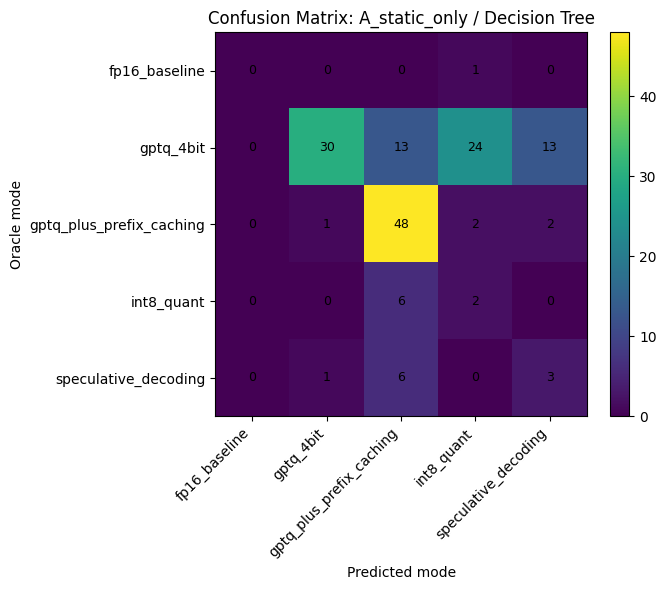

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/confusion_matrix_A_static_only_Decision_Tree.png

A_static_only | Random Forest
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/confusion_matrix_A_static_only_Random_Forest.csv


,fp16_baseline,gptq_4bit,gptq_plus_prefix_caching,int8_quant,speculative_decoding
fp16_baseline,0,0,0,1,0
gptq_4bit,0,43,13,24,0
gptq_plus_prefix_caching,0,3,48,2,0
int8_quant,0,0,6,2,0
speculative_decoding,0,4,6,0,0


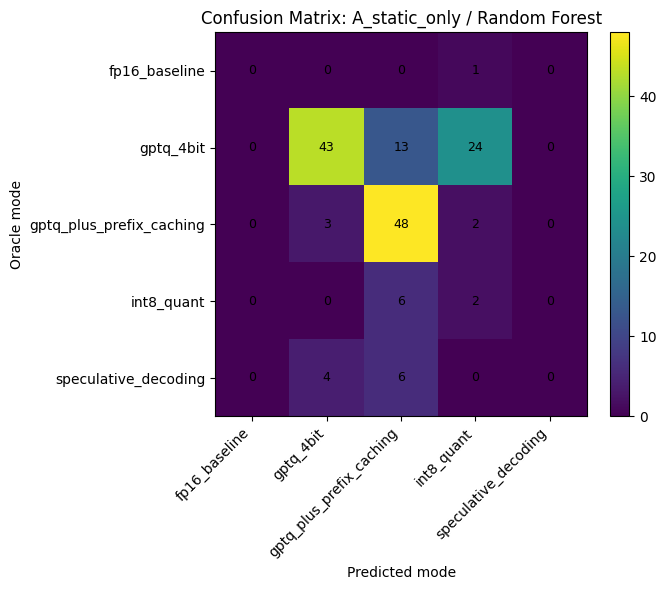

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/confusion_matrix_A_static_only_Random_Forest.png

A_static_only | Logistic Regression
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/confusion_matrix_A_static_only_Logistic_Regression.csv


,fp16_baseline,gptq_4bit,gptq_plus_prefix_caching,int8_quant,speculative_decoding
fp16_baseline,0,0,0,1,0
gptq_4bit,0,30,13,24,13
gptq_plus_prefix_caching,0,1,48,2,2
int8_quant,0,0,6,2,0
speculative_decoding,0,1,6,0,3


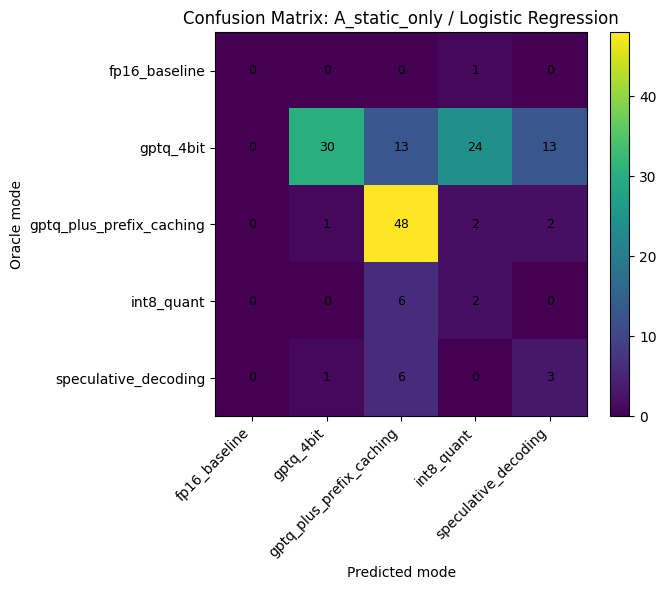

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/confusion_matrix_A_static_only_Logistic_Regression.png

B_with_workload_family | Decision Tree
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/confusion_matrix_B_with_workload_family_Decision_Tree.csv


,fp16_baseline,gptq_4bit,gptq_plus_prefix_caching,int8_quant,speculative_decoding
fp16_baseline,0,0,0,1,0
gptq_4bit,0,30,13,24,13
gptq_plus_prefix_caching,0,1,48,2,2
int8_quant,0,0,6,2,0
speculative_decoding,0,1,6,0,3


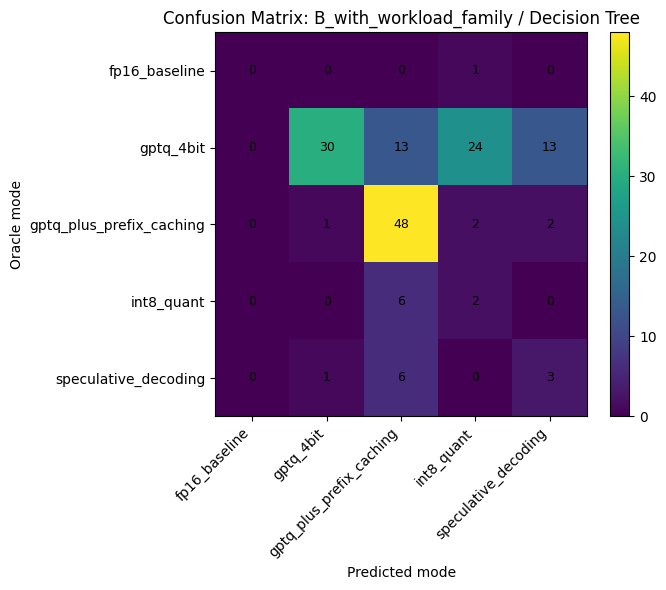

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/confusion_matrix_B_with_workload_family_Decision_Tree.png

B_with_workload_family | Random Forest
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/confusion_matrix_B_with_workload_family_Random_Forest.csv


,fp16_baseline,gptq_4bit,gptq_plus_prefix_caching,int8_quant,speculative_decoding
fp16_baseline,0,0,0,1,0
gptq_4bit,0,43,13,24,0
gptq_plus_prefix_caching,0,3,48,2,0
int8_quant,0,0,6,2,0
speculative_decoding,0,4,6,0,0


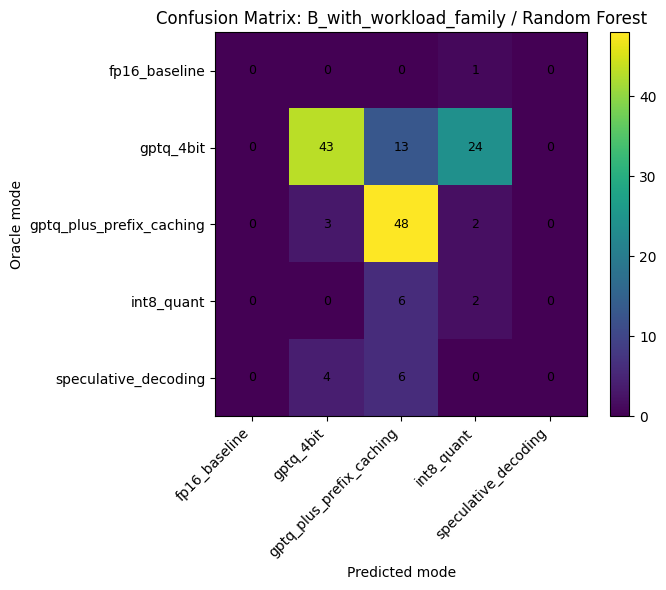

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/confusion_matrix_B_with_workload_family_Random_Forest.png

B_with_workload_family | Logistic Regression
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/confusion_matrix_B_with_workload_family_Logistic_Regression.csv


,fp16_baseline,gptq_4bit,gptq_plus_prefix_caching,int8_quant,speculative_decoding
fp16_baseline,0,0,0,1,0
gptq_4bit,0,30,13,24,13
gptq_plus_prefix_caching,0,1,48,2,2
int8_quant,0,0,6,2,0
speculative_decoding,0,1,6,0,3


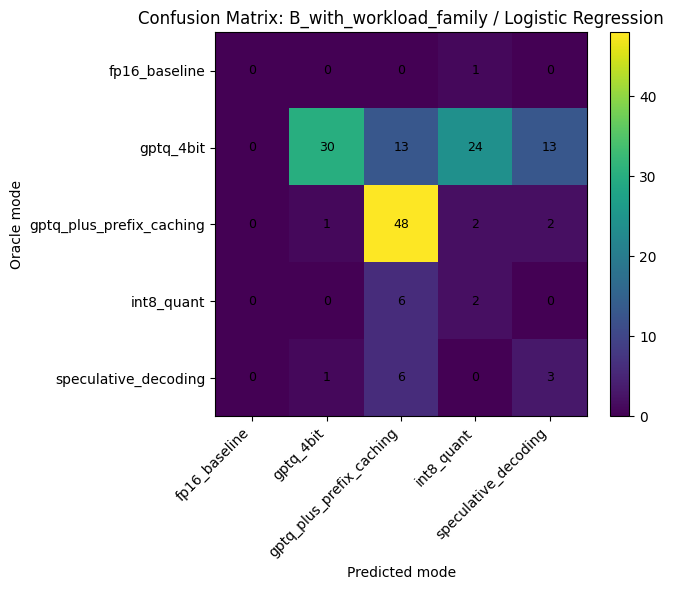

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/confusion_matrix_B_with_workload_family_Logistic_Regression.png


In [14]:
# ============================================================
# Cell 14: Confusion matrices
# ============================================================

confusion_rows = []

for (version_name, model_name), obj in trained_models.items():
    pipe = obj["pipeline"]
    feature_cols = obj["feature_cols"]

    y_true = test_df["oracle_mode"].copy()
    y_pred = pipe.predict(test_df[feature_cols].copy())

    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_path = TABLE_DIR / f"confusion_matrix_{version_name}_{model_name.replace(' ', '_')}.csv"
    cm_df.to_csv(cm_path)

    print("\n" + "=" * 100)
    print(version_name, "|", model_name)
    print("Saved:", cm_path)
    display(cm_df)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, aspect="auto")
    ax.set_title(f"Confusion Matrix: {version_name} / {model_name}")
    ax.set_xlabel("Predicted mode")
    ax.set_ylabel("Oracle mode")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    plt.colorbar(im, ax=ax)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=9)

    plt.tight_layout()

    fig_path = PLOT_DIR / f"confusion_matrix_{version_name}_{model_name.replace(' ', '_')}.png"
    plt.savefig(fig_path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)

In [15]:
# ============================================================
# Cell 15: Selected-mode counts
# ============================================================

mode_count_rows = []

# Oracle counts.
oracle_counts = (
    dataset_df["oracle_mode"]
    .value_counts()
    .rename_axis("selected_mode")
    .reset_index(name="count")
)
oracle_counts["policy_name"] = "constraint_aware_oracle"
oracle_counts["feature_version"] = "oracle"
oracle_counts["model_name"] = "oracle"
mode_count_rows.append(oracle_counts)

# Learned model counts.
for (version_name, model_name), obj in trained_models.items():
    sub = learned_predictions_df[
        (learned_predictions_df["feature_version"] == version_name)
        & (learned_predictions_df["model_name"] == model_name)
    ].copy()

    counts = (
        sub["predicted_mode"]
        .value_counts()
        .rename_axis("selected_mode")
        .reset_index(name="count")
    )
    counts["policy_name"] = f"{version_name}__{model_name}"
    counts["feature_version"] = version_name
    counts["model_name"] = model_name
    mode_count_rows.append(counts)

selected_mode_counts_df = pd.concat(mode_count_rows, ignore_index=True)

display(selected_mode_counts_df)
save_table(selected_mode_counts_df, "selected_mode_counts.csv")

,selected_mode,count,policy_name,feature_version,model_name
0,gptq_4bit,302,constraint_aware_oracle,oracle,oracle
1,gptq_plus_prefix_caching,202,constraint_aware_oracle,oracle,oracle
2,speculative_decoding,54,constraint_aware_oracle,oracle,oracle
3,int8_quant,46,constraint_aware_oracle,oracle,oracle
4,fp16_baseline,1,constraint_aware_oracle,oracle,oracle
5,gptq_plus_prefix_caching,300,A_static_only__Decision Tree,A_static_only,Decision Tree
6,int8_quant,104,A_static_only__Decision Tree,A_static_only,Decision Tree
7,speculative_decoding,101,A_static_only__Decision Tree,A_static_only,Decision Tree
8,gptq_4bit,100,A_static_only__Decision Tree,A_static_only,Decision Tree
9,gptq_plus_prefix_caching,300,A_static_only__Random Forest,A_static_only,Random Forest


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/selected_mode_counts.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/selected_mode_counts.csv')

In [16]:
# ============================================================
# Cell 16: Rule-based controller predictions
# ============================================================

def resolve_runtime_workload(workload_name: str):
    return build_runtime_workload_by_name(workload_name)


def measure_rule_controller_overhead(workload_keys, repeats=3):
    times_ms = []
    predictions = []

    for workload_key in workload_keys:
        try:
            runtime_workload = resolve_runtime_workload(workload_key)

            for _ in range(repeats):
                t0 = time.perf_counter()
                decision = route_runtime_workload(runtime_workload)
                t1 = time.perf_counter()
                times_ms.append((t1 - t0) * 1000.0)

            predictions.append({
                "workload_key": workload_key,
                "rule_selected_mode": decision.selected_mode_name,
                "rule_reason": decision.reason,
                "rule_phase_label": getattr(decision, "classification_label", None),
            })

        except Exception as exc:
            predictions.append({
                "workload_key": workload_key,
                "rule_selected_mode": BASELINE_MODE,
                "rule_reason": f"fallback_to_fp16_after_error: {exc}",
                "rule_phase_label": "error_fallback",
            })

    return pd.DataFrame(predictions), float(np.mean(times_ms)) if times_ms else np.nan


rule_predictions_df, rule_overhead_ms = measure_rule_controller_overhead(
    dataset_df["workload_key"].tolist(),
    repeats=3,
)

print("Rule controller mean CPU routing overhead:", rule_overhead_ms, "ms")

display(rule_predictions_df.head(20))
save_table(rule_predictions_df, "rule_based_controller_predictions.csv")

Rule controller mean CPU routing overhead: 0.009635845549382793 ms


,workload_key,rule_selected_mode,rule_reason,rule_phase_label
0,gpqa_eval,fp16_baseline,fallback_to_fp16_after_error: Workload 'gpqa_e...,error_fallback
1,gsm8k_eval,fp16_baseline,fallback_to_fp16_after_error: Workload 'gsm8k_...,error_fallback
2,long_prompt_long_output_v0,gptq_4bit,Long prompt + long output: GPTQ gives a strong...,synthetic_ll_balanced_gptq
3,long_prompt_long_output_v1,gptq_4bit,Long prompt + long output: GPTQ gives a strong...,synthetic_ll_balanced_gptq
4,long_prompt_long_output_v10,gptq_4bit,Long prompt + long output: GPTQ gives a strong...,synthetic_ll_balanced_gptq
5,long_prompt_long_output_v11,gptq_4bit,Long prompt + long output: GPTQ gives a strong...,synthetic_ll_balanced_gptq
6,long_prompt_long_output_v12,gptq_4bit,Long prompt + long output: GPTQ gives a strong...,synthetic_ll_balanced_gptq
7,long_prompt_long_output_v13,gptq_4bit,Long prompt + long output: GPTQ gives a strong...,synthetic_ll_balanced_gptq
8,long_prompt_long_output_v14,gptq_4bit,Long prompt + long output: GPTQ gives a strong...,synthetic_ll_balanced_gptq
9,long_prompt_long_output_v15,gptq_4bit,Long prompt + long output: GPTQ gives a strong...,synthetic_ll_balanced_gptq


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/rule_based_controller_predictions.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/rule_based_controller_predictions.csv')

In [17]:
# ============================================================
# Cell 17: Learned model overhead measurement
# ============================================================

def measure_single_request_predict_overhead_ms(pipe, X, repeats=500):
    """
    Measures CPU prediction overhead using one-row predict calls.
    """
    X = X.reset_index(drop=True).copy()

    if len(X) == 0:
        return np.nan

    # Warmup.
    for i in range(min(10, len(X))):
        _ = pipe.predict(X.iloc[[i]])

    t0 = time.perf_counter()

    for i in range(repeats):
        row = X.iloc[[i % len(X)]]
        _ = pipe.predict(row)

    t1 = time.perf_counter()

    return ((t1 - t0) * 1000.0) / repeats


overhead_rows = []

overhead_rows.append({
    "policy_name": "fp16_baseline",
    "feature_version": "fixed",
    "model_name": "fp16_baseline",
    "cpu_routing_overhead_ms": 0.0,
})

overhead_rows.append({
    "policy_name": "constraint_aware_oracle",
    "feature_version": "oracle",
    "model_name": "oracle",
    "cpu_routing_overhead_ms": 0.0,
})

overhead_rows.append({
    "policy_name": "hand_written_rule_controller",
    "feature_version": "rule",
    "model_name": "rule",
    "cpu_routing_overhead_ms": rule_overhead_ms,
})

for (version_name, model_name), obj in trained_models.items():
    pipe = obj["pipeline"]
    feature_cols = obj["feature_cols"]

    overhead_ms = measure_single_request_predict_overhead_ms(
        pipe,
        dataset_df[feature_cols].copy(),
        repeats=500,
    )

    overhead_rows.append({
        "policy_name": f"{version_name}__{model_name}",
        "feature_version": version_name,
        "model_name": model_name,
        "cpu_routing_overhead_ms": overhead_ms,
    })

overhead_df = pd.DataFrame(overhead_rows)

display(overhead_df.sort_values("cpu_routing_overhead_ms"))
save_table(overhead_df, "controller_routing_overhead.csv")

,policy_name,feature_version,model_name,cpu_routing_overhead_ms
0,fp16_baseline,fixed,fp16_baseline,0.000000
1,constraint_aware_oracle,oracle,oracle,0.000000
2,hand_written_rule_controller,rule,rule,0.009636
5,A_static_only__Logistic Regression,A_static_only,Logistic Regression,4.510398
3,A_static_only__Decision Tree,A_static_only,Decision Tree,4.606878
8,B_with_workload_family__Logistic Regression,B_with_workload_family,Logistic Regression,4.745120
6,B_with_workload_family__Decision Tree,B_with_workload_family,Decision Tree,4.771561
4,A_static_only__Random Forest,A_static_only,Random Forest,50.149022
7,B_with_workload_family__Random Forest,B_with_workload_family,Random Forest,50.289876


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/controller_routing_overhead.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/controller_routing_overhead.csv')

In [18]:
# ============================================================
# Cell 18: Routing-policy evaluator
# ============================================================

perf_lookup = perf_df.set_index(["workload_key", "mode_name"])
safety_lookup = candidate_safety_df.set_index(["workload_key", "mode_name"])
oracle_lookup = oracle_df.set_index("workload_key")


def get_perf_row(workload_key, mode_name):
    key = (workload_key, mode_name)
    if key in perf_lookup.index:
        return perf_lookup.loc[key]
    return None


def evaluate_policy(policy_name, row_df, selected_mode_by_workload, overhead_ms=0.0):
    rows = []

    for workload_key in row_df["workload_key"].tolist():
        selected_mode = selected_mode_by_workload.get(workload_key, BASELINE_MODE)

        selected_row = get_perf_row(workload_key, selected_mode)
        used_fallback = False

        if selected_row is None:
            selected_mode = BASELINE_MODE
            selected_row = get_perf_row(workload_key, selected_mode)
            used_fallback = True

        fp16_row = get_perf_row(workload_key, BASELINE_MODE)

        if selected_row is None or fp16_row is None:
            continue

        oracle_row = oracle_lookup.loc[workload_key] if workload_key in oracle_lookup.index else None
        oracle_mode = oracle_row["oracle_mode"] if oracle_row is not None else None
        oracle_perf_row = get_perf_row(workload_key, oracle_mode) if oracle_mode is not None else None

        selected_latency = safe_float(selected_row.get("total_latency_ms_mean"))
        selected_latency_with_overhead = selected_latency + safe_float(overhead_ms, 0.0)

        fp16_latency = safe_float(fp16_row.get("total_latency_ms_mean"))
        fp16_tps = safe_float(fp16_row.get("tokens_per_second_mean"))
        fp16_energy = safe_float(fp16_row.get("energy_per_token_j_mean"))
        fp16_memory = safe_float(fp16_row.get("peak_gpu_memory_mb_mean"))

        selected_tps = safe_float(selected_row.get("tokens_per_second_mean"))
        selected_energy = safe_float(selected_row.get("energy_per_token_j_mean"))
        selected_memory = safe_float(selected_row.get("peak_gpu_memory_mb_mean"))

        latency_speedup = fp16_latency / selected_latency_with_overhead
        throughput_ratio = selected_tps / fp16_tps
        energy_ratio = selected_energy / fp16_energy
        memory_ratio = selected_memory / fp16_memory

        if oracle_perf_row is not None:
            oracle_latency = safe_float(oracle_perf_row.get("total_latency_ms_mean"))
            oracle_energy = safe_float(oracle_perf_row.get("energy_per_token_j_mean"))
            latency_oracle_capture = oracle_latency / selected_latency_with_overhead
            energy_oracle_capture = oracle_energy / selected_energy
        else:
            latency_oracle_capture = np.nan
            energy_oracle_capture = np.nan

        safety_key = (workload_key, selected_mode)
        if safety_key in safety_lookup.index:
            safety_row = safety_lookup.loc[safety_key]
            quality_safe = bool(safety_row.get("quality_safe"))
            energy_safe = bool(safety_row.get("energy_safe"))
            memory_safe = bool(safety_row.get("memory_safe"))
            constraint_safe = bool(safety_row.get("constraint_safe"))
        else:
            quality_safe = selected_mode == BASELINE_MODE
            energy_safe = selected_mode == BASELINE_MODE
            memory_safe = selected_mode == BASELINE_MODE
            constraint_safe = selected_mode == BASELINE_MODE

        workload_family = canonical_workload_family_name(workload_key)
        metric_col = BENCHMARK_METRIC_MAP.get(workload_family)

        if metric_col is not None and metric_col in perf_df.columns:
            selected_acc = safe_float(selected_row.get(metric_col))
            fp16_acc = safe_float(fp16_row.get(metric_col))
            accuracy_delta_pts = 100.0 * (selected_acc - fp16_acc)
        else:
            accuracy_delta_pts = np.nan

        rows.append({
            "policy_name": policy_name,
            "workload_key": workload_key,
            "workload_family": workload_family,
            "selected_mode": selected_mode,
            "oracle_mode": oracle_mode,
            "matches_oracle_mode": selected_mode == oracle_mode,
            "used_fallback": used_fallback,

            "selected_latency_ms": selected_latency,
            "selected_latency_with_overhead_ms": selected_latency_with_overhead,
            "fp16_latency_ms": fp16_latency,
            "latency_speedup_vs_fp16": latency_speedup,
            "throughput_ratio_vs_fp16": throughput_ratio,
            "energy_ratio_vs_fp16": energy_ratio,
            "memory_ratio_vs_fp16": memory_ratio,

            "latency_oracle_capture": latency_oracle_capture,
            "energy_oracle_capture": energy_oracle_capture,

            "quality_safe": quality_safe,
            "energy_safe": energy_safe,
            "memory_safe": memory_safe,
            "constraint_safe": constraint_safe,
            "quality_risky": not quality_safe,

            "automatic_benchmark_accuracy_delta_pts": accuracy_delta_pts,
            "cpu_routing_overhead_ms": overhead_ms,
            "routing_overhead_pct_of_generation": 100.0 * overhead_ms / max(selected_latency, 1e-9),
        })

    return pd.DataFrame(rows)


def summarize_policy_eval(eval_df):
    if len(eval_df) == 0:
        return {}

    benchmark_rows = eval_df[eval_df["automatic_benchmark_accuracy_delta_pts"].notna()]

    return {
        "policy_name": eval_df["policy_name"].iloc[0],
        "num_workloads": len(eval_df),
        "oracle_mode_match_rate": eval_df["matches_oracle_mode"].mean(),
        "mean_latency_speedup_vs_fp16": eval_df["latency_speedup_vs_fp16"].mean(),
        "mean_throughput_ratio_vs_fp16": eval_df["throughput_ratio_vs_fp16"].mean(),
        "mean_energy_ratio_vs_fp16": eval_df["energy_ratio_vs_fp16"].mean(),
        "mean_energy_reduction_pct_vs_fp16": 100.0 * (1.0 - eval_df["energy_ratio_vs_fp16"].mean()),
        "mean_memory_ratio_vs_fp16": eval_df["memory_ratio_vs_fp16"].mean(),
        "mean_latency_oracle_capture_pct": 100.0 * eval_df["latency_oracle_capture"].mean(),
        "mean_energy_oracle_capture_pct": 100.0 * eval_df["energy_oracle_capture"].mean(),
        "mean_accuracy_delta_pts_auto_benchmarks": (
            benchmark_rows["automatic_benchmark_accuracy_delta_pts"].mean()
            if len(benchmark_rows) else np.nan
        ),
        "num_quality_risky_choices": int(eval_df["quality_risky"].sum()),
        "num_constraint_unsafe_choices": int((~eval_df["constraint_safe"]).sum()),
        "num_fallbacks": int(eval_df["used_fallback"].sum()),
        "mean_cpu_routing_overhead_ms": eval_df["cpu_routing_overhead_ms"].mean(),
        "mean_routing_overhead_pct_of_generation": eval_df["routing_overhead_pct_of_generation"].mean(),
    }

In [19]:
# ============================================================
# Cell 19: Evaluate FP16, oracle, rule controller, and learned controllers
# ============================================================

def evaluate_all_policies(eval_name, row_df):
    all_eval_dfs = []
    summary_rows = []

    workload_keys = row_df["workload_key"].tolist()

    # FP16 baseline.
    fp16_selected = {w: BASELINE_MODE for w in workload_keys}
    fp16_eval = evaluate_policy(
        policy_name=f"{eval_name}__fp16_baseline",
        row_df=row_df,
        selected_mode_by_workload=fp16_selected,
        overhead_ms=0.0,
    )
    all_eval_dfs.append(fp16_eval)
    summary_rows.append(summarize_policy_eval(fp16_eval))

    # Constraint-aware oracle.
    oracle_selected = {
        w: oracle_lookup.loc[w]["oracle_mode"]
        for w in workload_keys
        if w in oracle_lookup.index
    }
    oracle_eval = evaluate_policy(
        policy_name=f"{eval_name}__constraint_aware_oracle",
        row_df=row_df,
        selected_mode_by_workload=oracle_selected,
        overhead_ms=0.0,
    )
    all_eval_dfs.append(oracle_eval)
    summary_rows.append(summarize_policy_eval(oracle_eval))

    # Rule controller.
    rule_map = dict(zip(rule_predictions_df["workload_key"], rule_predictions_df["rule_selected_mode"]))
    rule_eval = evaluate_policy(
        policy_name=f"{eval_name}__hand_written_rule_controller",
        row_df=row_df,
        selected_mode_by_workload=rule_map,
        overhead_ms=rule_overhead_ms,
    )
    all_eval_dfs.append(rule_eval)
    summary_rows.append(summarize_policy_eval(rule_eval))

    # Learned models.
    for (version_name, model_name), obj in trained_models.items():
        pipe = obj["pipeline"]
        feature_cols = obj["feature_cols"]

        overhead_match = overhead_df[
            (overhead_df["feature_version"] == version_name)
            & (overhead_df["model_name"] == model_name)
        ]

        overhead_ms = float(overhead_match["cpu_routing_overhead_ms"].iloc[0]) if len(overhead_match) else 0.0

        pred_modes = pipe.predict(row_df[feature_cols].copy())
        pred_map = dict(zip(row_df["workload_key"], pred_modes))

        policy_name = f"{eval_name}__{version_name}__{model_name}"

        learned_eval = evaluate_policy(
            policy_name=policy_name,
            row_df=row_df,
            selected_mode_by_workload=pred_map,
            overhead_ms=overhead_ms,
        )

        all_eval_dfs.append(learned_eval)
        summary_rows.append(summarize_policy_eval(learned_eval))

    eval_detail_df = pd.concat(all_eval_dfs, ignore_index=True)
    eval_summary_df = pd.DataFrame(summary_rows)

    return eval_detail_df, eval_summary_df


test_eval_detail_df, test_eval_summary_df = evaluate_all_policies("test", test_df)
all_eval_detail_df, all_eval_summary_df = evaluate_all_policies("all", dataset_df)

test_eval_summary_df = test_eval_summary_df.sort_values(
    "mean_latency_speedup_vs_fp16",
    ascending=False,
).reset_index(drop=True)

all_eval_summary_df = all_eval_summary_df.sort_values(
    "mean_latency_speedup_vs_fp16",
    ascending=False,
).reset_index(drop=True)

print("TEST summary:")
display(test_eval_summary_df)

print("ALL-DATA summary:")
display(all_eval_summary_df)

save_table(test_eval_detail_df, "test_policy_eval_detail.csv")
save_table(test_eval_summary_df, "test_policy_eval_summary.csv")
save_table(all_eval_detail_df, "all_policy_eval_detail.csv")
save_table(all_eval_summary_df, "all_policy_eval_summary.csv")

TEST summary:


,policy_name,num_workloads,oracle_mode_match_rate,mean_latency_speedup_vs_fp16,mean_throughput_ratio_vs_fp16,mean_energy_ratio_vs_fp16,mean_energy_reduction_pct_vs_fp16,mean_memory_ratio_vs_fp16,mean_latency_oracle_capture_pct,mean_energy_oracle_capture_pct,mean_accuracy_delta_pts_auto_benchmarks,num_quality_risky_choices,num_constraint_unsafe_choices,num_fallbacks,mean_cpu_routing_overhead_ms,mean_routing_overhead_pct_of_generation
0,test__constraint_aware_oracle,152,1.000000,2.421360,2.417499,0.450639,54.936082,1.007858,100.000000,100.000000,0.0,0,0,0,0.000000,0.000000
1,test__hand_written_rule_controller,152,0.585526,2.398967,2.395269,0.469472,53.052797,1.007343,100.334006,97.132446,0.0,19,19,0,0.009636,0.001806
2,test__A_static_only__Logistic Regression,152,0.546053,2.265894,2.281132,0.460258,53.974232,1.007621,94.617660,99.474274,-4.0,16,16,0,4.510398,0.834676
3,test__A_static_only__Decision Tree,152,0.546053,2.265502,2.281132,0.460258,53.974232,1.007621,94.600093,99.474274,-4.0,16,16,0,4.606878,0.852530
4,test__B_with_workload_family__Logistic Regression,152,0.546053,2.264940,2.281132,0.460258,53.974232,1.007621,94.574944,99.474274,-4.0,16,16,0,4.745120,0.878113
5,test__B_with_workload_family__Decision Tree,152,0.546053,2.264832,2.281132,0.460258,53.974232,1.007621,94.570137,99.474274,-4.0,16,16,0,4.771561,0.883006
6,test__A_static_only__Random Forest,152,0.611842,2.188271,2.375997,0.442725,55.727462,1.007923,90.702591,102.751834,-4.0,20,20,0,50.149022,9.467023
7,test__B_with_workload_family__Random Forest,152,0.611842,2.187797,2.375997,0.442725,55.727462,1.007923,90.682122,102.751834,-4.0,20,20,0,50.289876,9.493613
8,test__fp16_baseline,152,0.006579,1.000000,1.000000,1.000000,0.000000,1.000000,42.206981,45.063918,0.0,0,0,0,0.000000,0.000000


ALL-DATA summary:


,policy_name,num_workloads,oracle_mode_match_rate,mean_latency_speedup_vs_fp16,mean_throughput_ratio_vs_fp16,mean_energy_ratio_vs_fp16,mean_energy_reduction_pct_vs_fp16,mean_memory_ratio_vs_fp16,mean_latency_oracle_capture_pct,mean_energy_oracle_capture_pct,mean_accuracy_delta_pts_auto_benchmarks,num_quality_risky_choices,num_constraint_unsafe_choices,num_fallbacks,mean_cpu_routing_overhead_ms,mean_routing_overhead_pct_of_generation
0,all__constraint_aware_oracle,605,1.000000,2.414170,2.409469,0.453634,54.636611,1.007795,100.000000,100.000000,1.0,0,0,0,0.000000,0.000000
1,all__hand_written_rule_controller,605,0.543802,2.380762,2.377266,0.472709,52.729132,1.007272,100.555601,97.924336,0.0,80,80,0,0.009636,0.001778
2,all__A_static_only__Logistic Regression,605,0.510744,2.261127,2.275165,0.463025,53.697469,1.007589,95.174713,100.153328,0.2,62,62,0,4.510398,0.820967
3,all__A_static_only__Decision Tree,605,0.510744,2.260742,2.275165,0.463025,53.697469,1.007589,95.157567,100.153328,0.2,62,62,0,4.606878,0.838528
4,all__B_with_workload_family__Logistic Regression,605,0.510744,2.260190,2.275165,0.463025,53.697469,1.007589,95.133020,100.153328,0.2,62,62,0,4.745120,0.863690
5,all__B_with_workload_family__Decision Tree,605,0.510744,2.260084,2.275165,0.463025,53.697469,1.007589,95.128328,100.153328,0.2,62,62,0,4.771561,0.868503
6,all__A_static_only__Random Forest,605,0.600000,2.225041,2.411865,0.437053,56.294695,1.008014,93.055291,105.029620,-0.4,86,86,0,50.149022,9.395926
7,all__B_with_workload_family__Random Forest,605,0.600000,2.223111,2.410337,0.437293,56.270653,1.008007,92.977031,104.981535,1.2,85,85,0,50.289876,9.419814
8,all__fp16_baseline,605,0.001653,1.000000,1.000000,1.000000,0.000000,1.000000,42.602013,45.363389,0.0,0,0,0,0.000000,0.000000


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/test_policy_eval_detail.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/test_policy_eval_summary.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/all_policy_eval_detail.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/all_policy_eval_summary.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/all_policy_eval_summary.csv')

In [20]:
# ============================================================
# Cell 20: Compare learned models against rule controller
# ============================================================

def add_rule_comparison(summary_df):
    out = summary_df.copy()

    rule_rows = out[out["policy_name"].str.contains("hand_written_rule_controller", regex=False)]
    if len(rule_rows) == 0:
        return out

    rule = rule_rows.iloc[0]

    out["latency_speedup_minus_rule"] = (
        out["mean_latency_speedup_vs_fp16"]
        - rule["mean_latency_speedup_vs_fp16"]
    )
    out["energy_ratio_minus_rule"] = (
        out["mean_energy_ratio_vs_fp16"]
        - rule["mean_energy_ratio_vs_fp16"]
    )
    out["oracle_match_rate_minus_rule"] = (
        out["oracle_mode_match_rate"]
        - rule["oracle_mode_match_rate"]
    )
    out["beats_rule_on_latency"] = out["latency_speedup_minus_rule"] > 0
    out["beats_rule_on_energy"] = out["energy_ratio_minus_rule"] < 0

    return out


test_rule_compare_df = add_rule_comparison(test_eval_summary_df)
all_rule_compare_df = add_rule_comparison(all_eval_summary_df)

print("TEST comparison vs rule:")
display(test_rule_compare_df)

print("ALL-DATA comparison vs rule:")
display(all_rule_compare_df)

save_table(test_rule_compare_df, "test_compare_vs_rule_controller.csv")
save_table(all_rule_compare_df, "all_compare_vs_rule_controller.csv")

TEST comparison vs rule:


,policy_name,num_workloads,oracle_mode_match_rate,mean_latency_speedup_vs_fp16,mean_throughput_ratio_vs_fp16,mean_energy_ratio_vs_fp16,mean_energy_reduction_pct_vs_fp16,mean_memory_ratio_vs_fp16,mean_latency_oracle_capture_pct,mean_energy_oracle_capture_pct,...,num_quality_risky_choices,num_constraint_unsafe_choices,num_fallbacks,mean_cpu_routing_overhead_ms,mean_routing_overhead_pct_of_generation,latency_speedup_minus_rule,energy_ratio_minus_rule,oracle_match_rate_minus_rule,beats_rule_on_latency,beats_rule_on_energy
0,test__constraint_aware_oracle,152,1.000000,2.421360,2.417499,0.450639,54.936082,1.007858,100.000000,100.000000,...,0,0,0,0.000000,0.000000,0.022393,-0.018833,0.414474,True,True
1,test__hand_written_rule_controller,152,0.585526,2.398967,2.395269,0.469472,53.052797,1.007343,100.334006,97.132446,...,19,19,0,0.009636,0.001806,0.000000,0.000000,0.000000,False,False
2,test__A_static_only__Logistic Regression,152,0.546053,2.265894,2.281132,0.460258,53.974232,1.007621,94.617660,99.474274,...,16,16,0,4.510398,0.834676,-0.133072,-0.009214,-0.039474,False,True
3,test__A_static_only__Decision Tree,152,0.546053,2.265502,2.281132,0.460258,53.974232,1.007621,94.600093,99.474274,...,16,16,0,4.606878,0.852530,-0.133465,-0.009214,-0.039474,False,True
4,test__B_with_workload_family__Logistic Regression,152,0.546053,2.264940,2.281132,0.460258,53.974232,1.007621,94.574944,99.474274,...,16,16,0,4.745120,0.878113,-0.134027,-0.009214,-0.039474,False,True
5,test__B_with_workload_family__Decision Tree,152,0.546053,2.264832,2.281132,0.460258,53.974232,1.007621,94.570137,99.474274,...,16,16,0,4.771561,0.883006,-0.134135,-0.009214,-0.039474,False,True
6,test__A_static_only__Random Forest,152,0.611842,2.188271,2.375997,0.442725,55.727462,1.007923,90.702591,102.751834,...,20,20,0,50.149022,9.467023,-0.210696,-0.026747,0.026316,False,True
7,test__B_with_workload_family__Random Forest,152,0.611842,2.187797,2.375997,0.442725,55.727462,1.007923,90.682122,102.751834,...,20,20,0,50.289876,9.493613,-0.211170,-0.026747,0.026316,False,True
8,test__fp16_baseline,152,0.006579,1.000000,1.000000,1.000000,0.000000,1.000000,42.206981,45.063918,...,0,0,0,0.000000,0.000000,-1.398967,0.530528,-0.578947,False,False


ALL-DATA comparison vs rule:


,policy_name,num_workloads,oracle_mode_match_rate,mean_latency_speedup_vs_fp16,mean_throughput_ratio_vs_fp16,mean_energy_ratio_vs_fp16,mean_energy_reduction_pct_vs_fp16,mean_memory_ratio_vs_fp16,mean_latency_oracle_capture_pct,mean_energy_oracle_capture_pct,...,num_quality_risky_choices,num_constraint_unsafe_choices,num_fallbacks,mean_cpu_routing_overhead_ms,mean_routing_overhead_pct_of_generation,latency_speedup_minus_rule,energy_ratio_minus_rule,oracle_match_rate_minus_rule,beats_rule_on_latency,beats_rule_on_energy
0,all__constraint_aware_oracle,605,1.000000,2.414170,2.409469,0.453634,54.636611,1.007795,100.000000,100.000000,...,0,0,0,0.000000,0.000000,0.033408,-0.019075,0.456198,True,True
1,all__hand_written_rule_controller,605,0.543802,2.380762,2.377266,0.472709,52.729132,1.007272,100.555601,97.924336,...,80,80,0,0.009636,0.001778,0.000000,0.000000,0.000000,False,False
2,all__A_static_only__Logistic Regression,605,0.510744,2.261127,2.275165,0.463025,53.697469,1.007589,95.174713,100.153328,...,62,62,0,4.510398,0.820967,-0.119634,-0.009683,-0.033058,False,True
3,all__A_static_only__Decision Tree,605,0.510744,2.260742,2.275165,0.463025,53.697469,1.007589,95.157567,100.153328,...,62,62,0,4.606878,0.838528,-0.120020,-0.009683,-0.033058,False,True
4,all__B_with_workload_family__Logistic Regression,605,0.510744,2.260190,2.275165,0.463025,53.697469,1.007589,95.133020,100.153328,...,62,62,0,4.745120,0.863690,-0.120572,-0.009683,-0.033058,False,True
5,all__B_with_workload_family__Decision Tree,605,0.510744,2.260084,2.275165,0.463025,53.697469,1.007589,95.128328,100.153328,...,62,62,0,4.771561,0.868503,-0.120677,-0.009683,-0.033058,False,True
6,all__A_static_only__Random Forest,605,0.600000,2.225041,2.411865,0.437053,56.294695,1.008014,93.055291,105.029620,...,86,86,0,50.149022,9.395926,-0.155720,-0.035656,0.056198,False,True
7,all__B_with_workload_family__Random Forest,605,0.600000,2.223111,2.410337,0.437293,56.270653,1.008007,92.977031,104.981535,...,85,85,0,50.289876,9.419814,-0.157651,-0.035415,0.056198,False,True
8,all__fp16_baseline,605,0.001653,1.000000,1.000000,1.000000,0.000000,1.000000,42.602013,45.363389,...,0,0,0,0.000000,0.000000,-1.380762,0.527291,-0.542149,False,False


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/test_compare_vs_rule_controller.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/all_compare_vs_rule_controller.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/all_compare_vs_rule_controller.csv')

In [21]:
# ============================================================
# Cell 21: Quality-risky choices
# ============================================================

quality_risky_df = all_eval_detail_df[
    all_eval_detail_df["quality_risky"]
].copy()

constraint_unsafe_df = all_eval_detail_df[
    ~all_eval_detail_df["constraint_safe"]
].copy()

print("Quality-risky choices:", len(quality_risky_df))
display(quality_risky_df[[
    "policy_name",
    "workload_key",
    "workload_family",
    "selected_mode",
    "oracle_mode",
    "quality_safe",
    "energy_safe",
    "memory_safe",
    "constraint_safe",
    "automatic_benchmark_accuracy_delta_pts",
]].head(100))

print("Constraint-unsafe choices:", len(constraint_unsafe_df))
display(constraint_unsafe_df[[
    "policy_name",
    "workload_key",
    "workload_family",
    "selected_mode",
    "oracle_mode",
    "quality_safe",
    "energy_safe",
    "memory_safe",
    "constraint_safe",
    "automatic_benchmark_accuracy_delta_pts",
]].head(100))

save_table(quality_risky_df, "quality_risky_choices.csv")
save_table(constraint_unsafe_df, "constraint_unsafe_choices.csv")

Quality-risky choices: 499


,policy_name,workload_key,workload_family,selected_mode,oracle_mode,quality_safe,energy_safe,memory_safe,constraint_safe,automatic_benchmark_accuracy_delta_pts
1241,all__hand_written_rule_controller,long_prompt_long_output_v35,long_prompt_long_output,gptq_4bit,int8_quant,False,True,True,False,NaN
1242,all__hand_written_rule_controller,long_prompt_long_output_v36,long_prompt_long_output,gptq_4bit,speculative_decoding,False,True,True,False,NaN
1265,all__hand_written_rule_controller,long_prompt_long_output_v57,long_prompt_long_output,gptq_4bit,gptq_plus_prefix_caching,False,True,True,False,NaN
1274,all__hand_written_rule_controller,long_prompt_long_output_v65,long_prompt_long_output,gptq_4bit,gptq_plus_prefix_caching,False,True,True,False,NaN
1277,all__hand_written_rule_controller,long_prompt_long_output_v68,long_prompt_long_output,gptq_4bit,speculative_decoding,False,True,True,False,NaN
...,...,...,...,...,...,...,...,...,...,...
1968,all__A_static_only__Decision Tree,long_prompt_short_output_v55,long_prompt_short_output,gptq_plus_prefix_caching,speculative_decoding,False,True,True,False,NaN
1971,all__A_static_only__Decision Tree,long_prompt_short_output_v58,long_prompt_short_output,gptq_plus_prefix_caching,speculative_decoding,False,True,True,False,NaN
1974,all__A_static_only__Decision Tree,long_prompt_short_output_v60,long_prompt_short_output,gptq_plus_prefix_caching,int8_quant,False,True,True,False,NaN
1981,all__A_static_only__Decision Tree,long_prompt_short_output_v67,long_prompt_short_output,gptq_plus_prefix_caching,speculative_decoding,False,True,True,False,NaN


Constraint-unsafe choices: 499


,policy_name,workload_key,workload_family,selected_mode,oracle_mode,quality_safe,energy_safe,memory_safe,constraint_safe,automatic_benchmark_accuracy_delta_pts
1241,all__hand_written_rule_controller,long_prompt_long_output_v35,long_prompt_long_output,gptq_4bit,int8_quant,False,True,True,False,NaN
1242,all__hand_written_rule_controller,long_prompt_long_output_v36,long_prompt_long_output,gptq_4bit,speculative_decoding,False,True,True,False,NaN
1265,all__hand_written_rule_controller,long_prompt_long_output_v57,long_prompt_long_output,gptq_4bit,gptq_plus_prefix_caching,False,True,True,False,NaN
1274,all__hand_written_rule_controller,long_prompt_long_output_v65,long_prompt_long_output,gptq_4bit,gptq_plus_prefix_caching,False,True,True,False,NaN
1277,all__hand_written_rule_controller,long_prompt_long_output_v68,long_prompt_long_output,gptq_4bit,speculative_decoding,False,True,True,False,NaN
...,...,...,...,...,...,...,...,...,...,...
1968,all__A_static_only__Decision Tree,long_prompt_short_output_v55,long_prompt_short_output,gptq_plus_prefix_caching,speculative_decoding,False,True,True,False,NaN
1971,all__A_static_only__Decision Tree,long_prompt_short_output_v58,long_prompt_short_output,gptq_plus_prefix_caching,speculative_decoding,False,True,True,False,NaN
1974,all__A_static_only__Decision Tree,long_prompt_short_output_v60,long_prompt_short_output,gptq_plus_prefix_caching,int8_quant,False,True,True,False,NaN
1981,all__A_static_only__Decision Tree,long_prompt_short_output_v67,long_prompt_short_output,gptq_plus_prefix_caching,speculative_decoding,False,True,True,False,NaN


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/quality_risky_choices.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/constraint_unsafe_choices.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/constraint_unsafe_choices.csv')

In [22]:
# ============================================================
# Cell 22: Per-workload policy comparison table
# ============================================================

# Pick best learned model by test latency speedup, excluding FP16/oracle/rule.
learned_test_rows = test_eval_summary_df[
    test_eval_summary_df["policy_name"].str.contains("A_static_only")
    | test_eval_summary_df["policy_name"].str.contains("B_with_workload_family")
].copy()

if len(learned_test_rows) > 0:
    best_learned_policy = learned_test_rows.sort_values(
        [
            "num_constraint_unsafe_choices",
            "mean_latency_speedup_vs_fp16",
            "mean_energy_ratio_vs_fp16",
        ],
        ascending=[True, False, True],
    ).iloc[0]["policy_name"]
else:
    best_learned_policy = None

print("Best learned policy:", best_learned_policy)

policies_to_compare = [
    "all__fp16_baseline",
    "all__constraint_aware_oracle",
    "all__hand_written_rule_controller",
]

if best_learned_policy is not None:
    # Convert test__... policy to all__...
    policies_to_compare.append(best_learned_policy.replace("test__", "all__"))

comparison_detail_df = all_eval_detail_df[
    all_eval_detail_df["policy_name"].isin(policies_to_compare)
].copy()

wide_compare_df = comparison_detail_df.pivot_table(
    index=["workload_key", "workload_family"],
    columns="policy_name",
    values=[
        "selected_mode",
        "latency_speedup_vs_fp16",
        "energy_ratio_vs_fp16",
        "memory_ratio_vs_fp16",
        "constraint_safe",
    ],
    aggfunc="first",
)

wide_compare_df.columns = [
    f"{metric}__{policy}"
    for metric, policy in wide_compare_df.columns
]

wide_compare_df = wide_compare_df.reset_index()

display(wide_compare_df.head(50))
save_table(wide_compare_df, "per_workload_policy_comparison_wide.csv")

Best learned policy: test__A_static_only__Logistic Regression


,workload_key,workload_family,constraint_safe__all__A_static_only__Logistic Regression,constraint_safe__all__constraint_aware_oracle,constraint_safe__all__fp16_baseline,constraint_safe__all__hand_written_rule_controller,energy_ratio_vs_fp16__all__A_static_only__Logistic Regression,energy_ratio_vs_fp16__all__constraint_aware_oracle,energy_ratio_vs_fp16__all__fp16_baseline,energy_ratio_vs_fp16__all__hand_written_rule_controller,...,latency_speedup_vs_fp16__all__fp16_baseline,latency_speedup_vs_fp16__all__hand_written_rule_controller,memory_ratio_vs_fp16__all__A_static_only__Logistic Regression,memory_ratio_vs_fp16__all__constraint_aware_oracle,memory_ratio_vs_fp16__all__fp16_baseline,memory_ratio_vs_fp16__all__hand_written_rule_controller,selected_mode__all__A_static_only__Logistic Regression,selected_mode__all__constraint_aware_oracle,selected_mode__all__fp16_baseline,selected_mode__all__hand_written_rule_controller
0,gpqa_eval,gpqa_eval,False,True,True,True,0.793461,1.000000,1.0,1.000000,...,1.0,0.999820,1.005305,1.000000,1.0,1.000000,int8_quant,fp16_baseline,fp16_baseline,fp16_baseline
1,gsm8k_eval,gsm8k_eval,True,True,True,True,0.412365,0.412365,1.0,1.000000,...,1.0,0.999997,1.006837,1.006837,1.0,1.000000,speculative_decoding,speculative_decoding,fp16_baseline,fp16_baseline
2,long_prompt_long_output_v0,long_prompt_long_output,True,True,True,True,0.432779,0.432779,1.0,0.432779,...,1.0,2.557677,1.008126,1.008126,1.0,1.008126,gptq_4bit,gptq_4bit,fp16_baseline,gptq_4bit
3,long_prompt_long_output_v1,long_prompt_long_output,True,True,True,True,0.447372,0.447372,1.0,0.447372,...,1.0,2.566895,1.008152,1.008152,1.0,1.008152,gptq_4bit,gptq_4bit,fp16_baseline,gptq_4bit
4,long_prompt_long_output_v10,long_prompt_long_output,True,True,True,True,0.431337,0.431337,1.0,0.431337,...,1.0,2.537893,1.008145,1.008145,1.0,1.008145,gptq_4bit,gptq_4bit,fp16_baseline,gptq_4bit
5,long_prompt_long_output_v11,long_prompt_long_output,True,True,True,True,0.446761,0.446761,1.0,0.446761,...,1.0,2.548882,1.008132,1.008132,1.0,1.008132,gptq_4bit,gptq_4bit,fp16_baseline,gptq_4bit
6,long_prompt_long_output_v12,long_prompt_long_output,True,True,True,True,0.436516,0.436516,1.0,0.436516,...,1.0,2.585936,1.008126,1.008126,1.0,1.008126,gptq_4bit,gptq_4bit,fp16_baseline,gptq_4bit
7,long_prompt_long_output_v13,long_prompt_long_output,True,True,True,True,0.450060,0.450060,1.0,0.450060,...,1.0,2.578642,1.008152,1.008152,1.0,1.008152,gptq_4bit,gptq_4bit,fp16_baseline,gptq_4bit
8,long_prompt_long_output_v14,long_prompt_long_output,True,True,True,True,0.441700,0.441700,1.0,0.441700,...,1.0,2.570347,1.008145,1.008145,1.0,1.008145,gptq_4bit,gptq_4bit,fp16_baseline,gptq_4bit
9,long_prompt_long_output_v15,long_prompt_long_output,True,True,True,True,0.423403,0.423403,1.0,0.423403,...,1.0,2.551053,1.008132,1.008132,1.0,1.008132,gptq_4bit,gptq_4bit,fp16_baseline,gptq_4bit


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/per_workload_policy_comparison_wide.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/per_workload_policy_comparison_wide.csv')

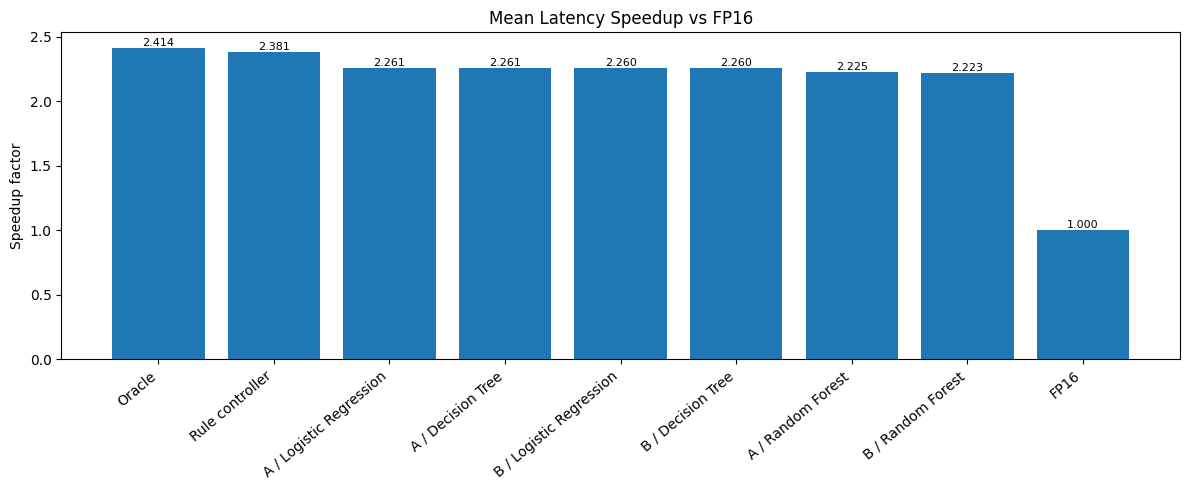

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/policy_latency_speedup_vs_fp16.png


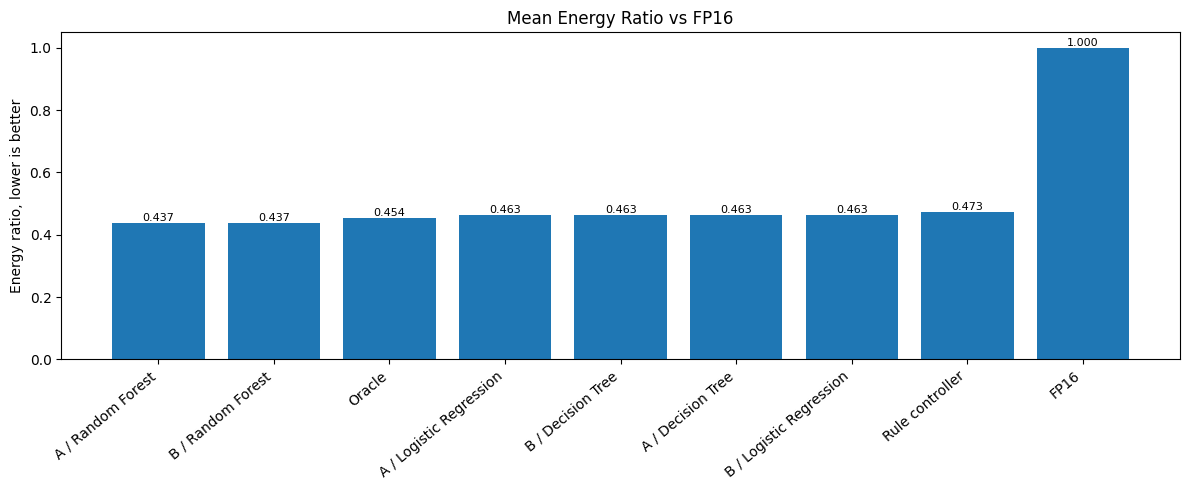

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/policy_energy_ratio_vs_fp16.png


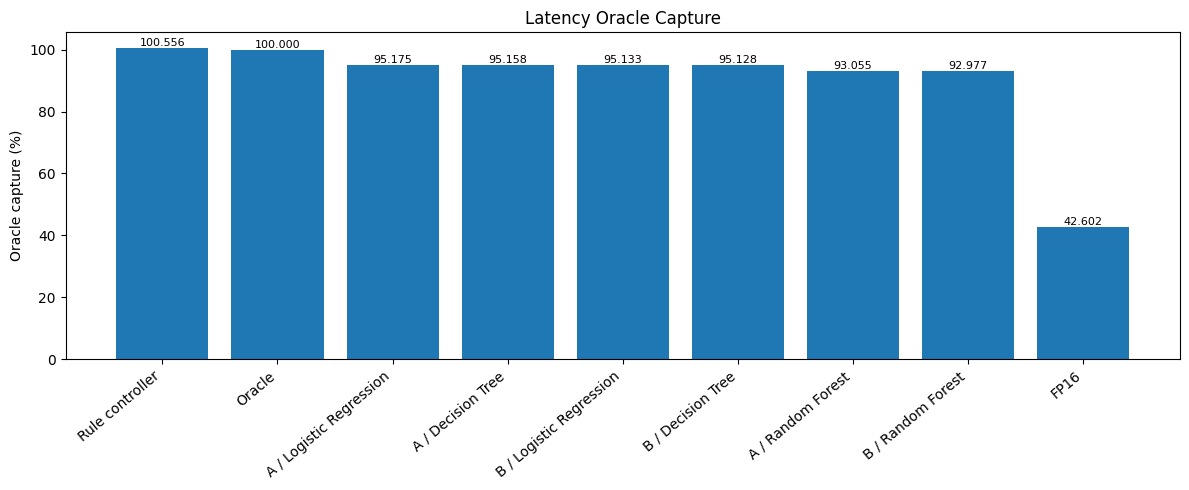

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/policy_latency_oracle_capture.png


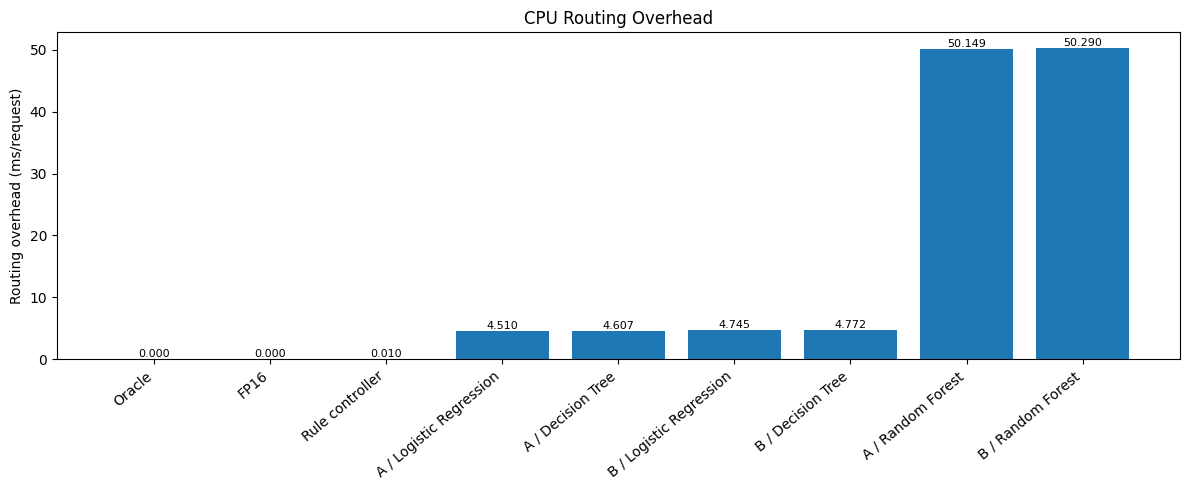

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/policy_cpu_routing_overhead.png


In [23]:
# ============================================================
# Cell 23: Plot summary metrics
# ============================================================

plot_summary_df = all_eval_summary_df.copy()

# Cleaner names for plots.
plot_summary_df["policy_short"] = (
    plot_summary_df["policy_name"]
    .str.replace("all__", "", regex=False)
    .str.replace("A_static_only__", "A / ", regex=False)
    .str.replace("B_with_workload_family__", "B / ", regex=False)
    .str.replace("hand_written_rule_controller", "Rule controller", regex=False)
    .str.replace("constraint_aware_oracle", "Oracle", regex=False)
    .str.replace("fp16_baseline", "FP16", regex=False)
)

# Keep main policies only.
main_plot_df = plot_summary_df.copy()

def plot_policy_bar(df, metric_col, title, ylabel, filename, higher_better=True):
    plot_df = df.sort_values(metric_col, ascending=not higher_better).copy()

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(plot_df))
    y = plot_df[metric_col].values

    ax.bar(x, y)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["policy_short"], rotation=40, ha="right")

    for i, value in enumerate(y):
        if pd.notna(value):
            ax.text(i, value, f"{value:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()

    path = PLOT_DIR / filename
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()

    print("Saved:", path)


plot_policy_bar(
    main_plot_df,
    "mean_latency_speedup_vs_fp16",
    "Mean Latency Speedup vs FP16",
    "Speedup factor",
    "policy_latency_speedup_vs_fp16.png",
    higher_better=True,
)

plot_policy_bar(
    main_plot_df,
    "mean_energy_ratio_vs_fp16",
    "Mean Energy Ratio vs FP16",
    "Energy ratio, lower is better",
    "policy_energy_ratio_vs_fp16.png",
    higher_better=False,
)

plot_policy_bar(
    main_plot_df,
    "mean_latency_oracle_capture_pct",
    "Latency Oracle Capture",
    "Oracle capture (%)",
    "policy_latency_oracle_capture.png",
    higher_better=True,
)

plot_policy_bar(
    main_plot_df,
    "mean_cpu_routing_overhead_ms",
    "CPU Routing Overhead",
    "Routing overhead (ms/request)",
    "policy_cpu_routing_overhead.png",
    higher_better=False,
)

,selected_mode,count
0,gptq_plus_prefix_caching,300
1,int8_quant,104
2,speculative_decoding,101
3,gptq_4bit,100


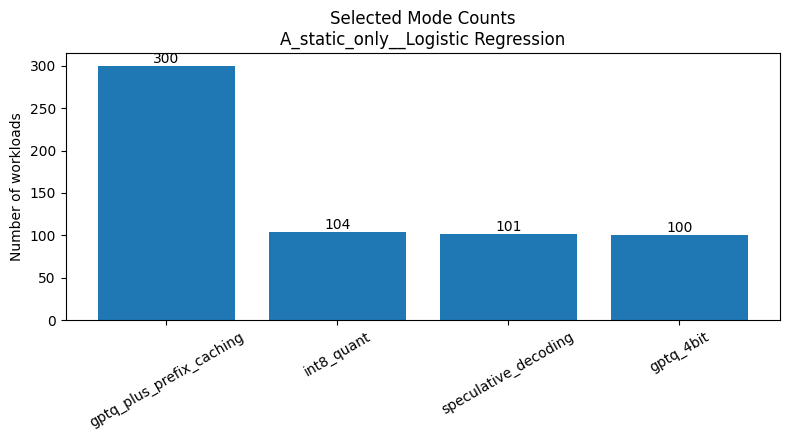

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/best_learned_model_selected_mode_counts.png


In [24]:
# ============================================================
# Cell 24: Plot selected-mode counts for best learned model
# ============================================================

if best_learned_policy is not None:
    best_all_policy = best_learned_policy.replace("test__", "all__")

    count_df = (
        all_eval_detail_df[all_eval_detail_df["policy_name"] == best_all_policy]
        ["selected_mode"]
        .value_counts()
        .rename_axis("selected_mode")
        .reset_index(name="count")
    )

    display(count_df)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(count_df["selected_mode"], count_df["count"])
    ax.set_title(f"Selected Mode Counts\n{best_all_policy.replace('all__', '')}")
    ax.set_ylabel("Number of workloads")
    ax.tick_params(axis="x", rotation=30)

    for i, value in enumerate(count_df["count"]):
        ax.text(i, value, str(value), ha="center", va="bottom")

    plt.tight_layout()

    path = PLOT_DIR / "best_learned_model_selected_mode_counts.png"
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()

    print("Saved:", path)
else:
    print("No learned policy available.")

,feature_version,model_name,feature,importance
6,A_static_only,Decision Tree,num__shared_prefix_int,0.330148
4,A_static_only,Decision Tree,num__log_expected_output_tokens,0.307171
19,A_static_only,Decision Tree,cat__benchmark_family_synthetic,0.139420
0,A_static_only,Decision Tree,num__prompt_tokens,0.130909
7,A_static_only,Decision Tree,num__memory_pressure_int,0.060810
...,...,...,...,...
147,B_with_workload_family,Logistic Regression,cat__workload_tag_long_prompt_long_output,0.363611
129,B_with_workload_family,Logistic Regression,num__log_expected_output_tokens,0.278617
148,B_with_workload_family,Logistic Regression,cat__workload_tag_long_prompt_short_output,0.267970
154,B_with_workload_family,Logistic Regression,cat__workload_tag_short_prompt_short_output,0.263177


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/feature_importance.csv


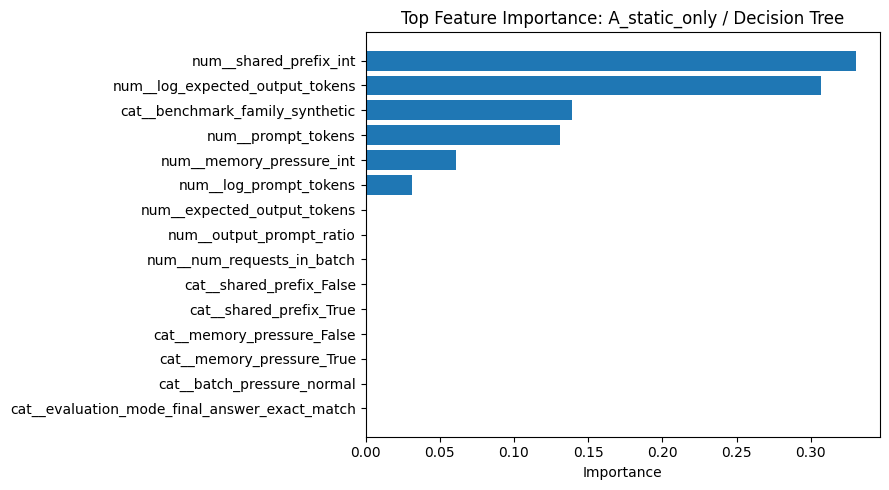

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/feature_importance_A_static_only_Decision_Tree.png


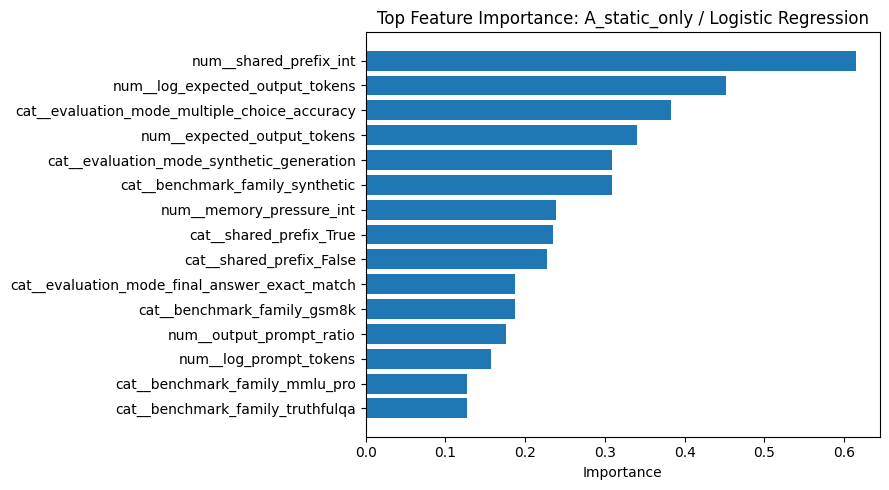

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/feature_importance_A_static_only_Logistic_Regression.png


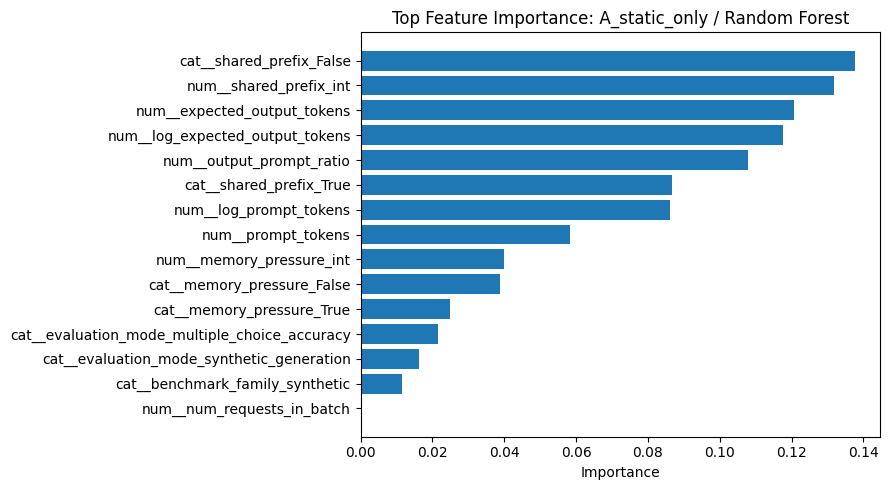

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/feature_importance_A_static_only_Random_Forest.png


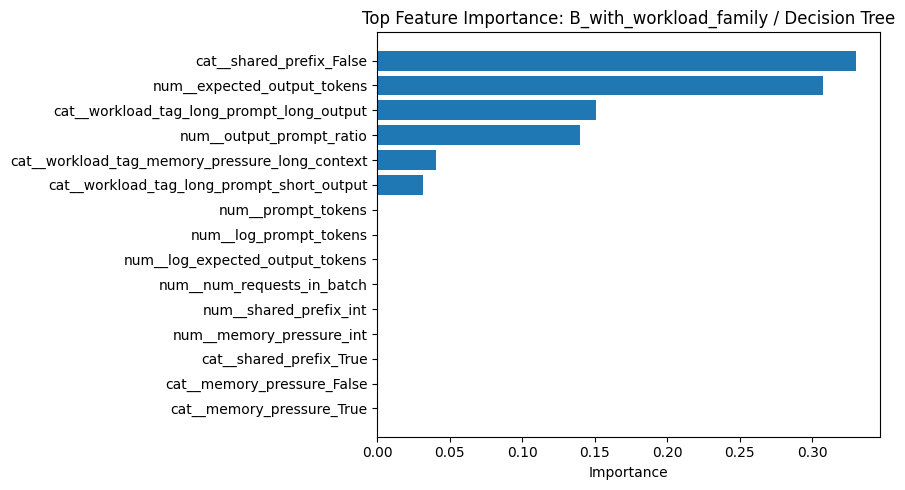

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/feature_importance_B_with_workload_family_Decision_Tree.png


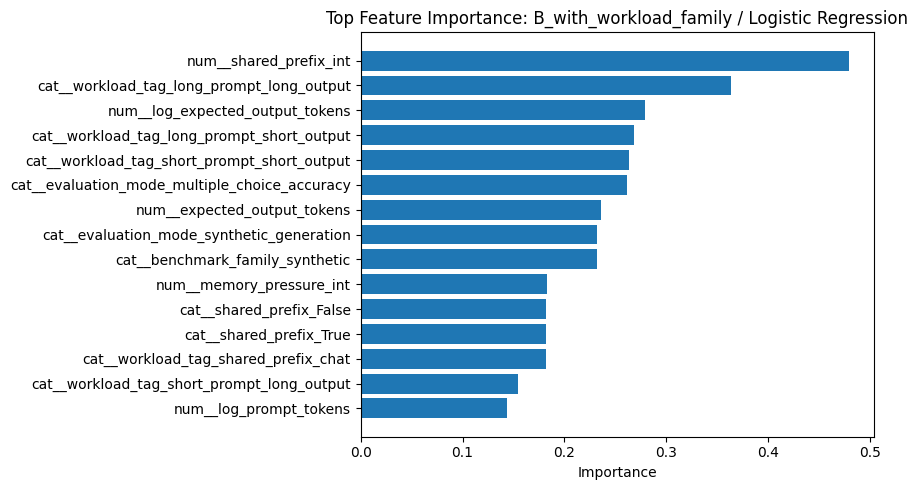

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/feature_importance_B_with_workload_family_Logistic_Regression.png


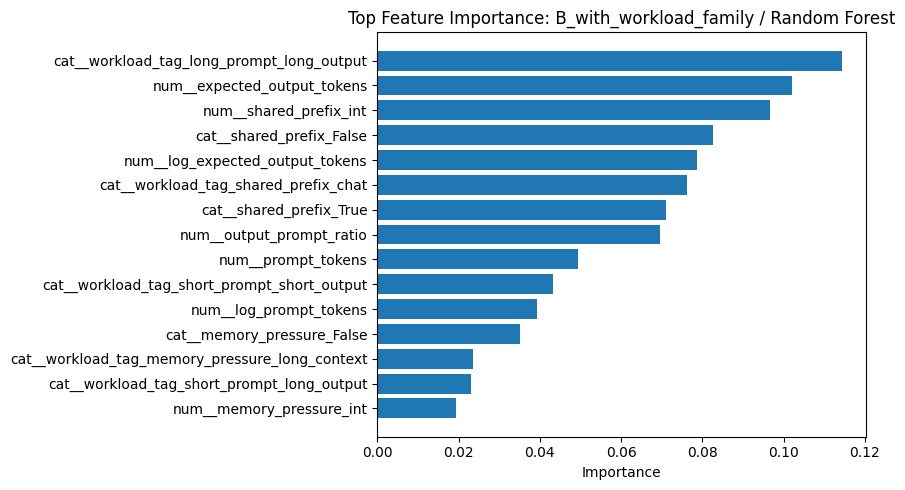

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/feature_importance_B_with_workload_family_Random_Forest.png


In [25]:
# ============================================================
# Cell 25: Model-specific feature importance
# ============================================================

importance_rows = []

for (version_name, model_name), obj in trained_models.items():
    pipe = obj["pipeline"]
    model = pipe.named_steps["model"]
    preprocessor = pipe.named_steps["preprocess"]

    try:
        feature_names = preprocessor.get_feature_names_out()

        if hasattr(model, "feature_importances_"):
            values = model.feature_importances_

        elif hasattr(model, "coef_"):
            values = np.mean(np.abs(model.coef_), axis=0)

        else:
            continue

        for feature_name, importance in zip(feature_names, values):
            importance_rows.append({
                "feature_version": version_name,
                "model_name": model_name,
                "feature": feature_name,
                "importance": float(importance),
            })

    except Exception as exc:
        print("Could not extract feature importance for", version_name, model_name, ":", exc)

feature_importance_df = pd.DataFrame(importance_rows)

if len(feature_importance_df) > 0:
    feature_importance_df = feature_importance_df.sort_values(
        ["feature_version", "model_name", "importance"],
        ascending=[True, True, False],
    )

    display(feature_importance_df.head(100))
    save_table(feature_importance_df, "feature_importance.csv")

    for (version_name, model_name), sub in feature_importance_df.groupby(["feature_version", "model_name"]):
        top = sub.head(15).copy()

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.barh(top["feature"][::-1], top["importance"][::-1])
        ax.set_title(f"Top Feature Importance: {version_name} / {model_name}")
        ax.set_xlabel("Importance")

        plt.tight_layout()

        path = PLOT_DIR / f"feature_importance_{version_name}_{model_name.replace(' ', '_')}.png"
        plt.savefig(path, dpi=250, bbox_inches="tight")
        plt.show()

        print("Saved:", path)

else:
    print("No feature importance available for these models.")

In [26]:
# ============================================================
# Cell 26: Final paper-ready summary
# ============================================================

final_summary_rows = []

for _, row in all_eval_summary_df.iterrows():
    policy = row["policy_name"]

    if "fp16_baseline" in policy:
        policy_type = "baseline"
    elif "constraint_aware_oracle" in policy:
        policy_type = "oracle"
    elif "hand_written_rule_controller" in policy:
        policy_type = "rule_controller"
    else:
        policy_type = "learned_controller"

    final_summary_rows.append({
        "policy_name": policy,
        "policy_type": policy_type,
        "oracle_mode_match_rate": row["oracle_mode_match_rate"],
        "mean_latency_speedup_vs_fp16": row["mean_latency_speedup_vs_fp16"],
        "mean_throughput_ratio_vs_fp16": row["mean_throughput_ratio_vs_fp16"],
        "mean_energy_ratio_vs_fp16": row["mean_energy_ratio_vs_fp16"],
        "mean_energy_reduction_pct_vs_fp16": row["mean_energy_reduction_pct_vs_fp16"],
        "mean_memory_ratio_vs_fp16": row["mean_memory_ratio_vs_fp16"],
        "mean_latency_oracle_capture_pct": row["mean_latency_oracle_capture_pct"],
        "mean_energy_oracle_capture_pct": row["mean_energy_oracle_capture_pct"],
        "mean_accuracy_delta_pts_auto_benchmarks": row["mean_accuracy_delta_pts_auto_benchmarks"],
        "num_quality_risky_choices": row["num_quality_risky_choices"],
        "num_constraint_unsafe_choices": row["num_constraint_unsafe_choices"],
        "mean_cpu_routing_overhead_ms": row["mean_cpu_routing_overhead_ms"],
        "mean_routing_overhead_pct_of_generation": row["mean_routing_overhead_pct_of_generation"],
    })

final_summary_df = pd.DataFrame(final_summary_rows)

final_summary_df = final_summary_df.sort_values(
    ["policy_type", "mean_latency_speedup_vs_fp16"],
    ascending=[True, False],
).reset_index(drop=True)

display(final_summary_df)

save_table(final_summary_df, "final_learnable_controller_summary.csv")

paper_display_df = final_summary_df.copy()
paper_display_df["latency_speedup"] = paper_display_df["mean_latency_speedup_vs_fp16"].map(lambda x: f"{x:.2f}×")
paper_display_df["throughput_ratio"] = paper_display_df["mean_throughput_ratio_vs_fp16"].map(lambda x: f"{x:.2f}×")
paper_display_df["energy_ratio"] = paper_display_df["mean_energy_ratio_vs_fp16"].map(lambda x: f"{x:.2f}×")
paper_display_df["memory_ratio"] = paper_display_df["mean_memory_ratio_vs_fp16"].map(lambda x: f"{x:.3f}×")
paper_display_df["oracle_match"] = paper_display_df["oracle_mode_match_rate"].map(lambda x: f"{100*x:.1f}%")
paper_display_df["overhead_ms"] = paper_display_df["mean_cpu_routing_overhead_ms"].map(lambda x: f"{x:.4f} ms")

paper_display_df = paper_display_df[[
    "policy_name",
    "policy_type",
    "latency_speedup",
    "throughput_ratio",
    "energy_ratio",
    "memory_ratio",
    "oracle_match",
    "mean_accuracy_delta_pts_auto_benchmarks",
    "num_quality_risky_choices",
    "num_constraint_unsafe_choices",
    "overhead_ms",
]]

display(paper_display_df)

save_table(paper_display_df, "paper_ready_learnable_controller_table.csv")

,policy_name,policy_type,oracle_mode_match_rate,mean_latency_speedup_vs_fp16,mean_throughput_ratio_vs_fp16,mean_energy_ratio_vs_fp16,mean_energy_reduction_pct_vs_fp16,mean_memory_ratio_vs_fp16,mean_latency_oracle_capture_pct,mean_energy_oracle_capture_pct,mean_accuracy_delta_pts_auto_benchmarks,num_quality_risky_choices,num_constraint_unsafe_choices,mean_cpu_routing_overhead_ms,mean_routing_overhead_pct_of_generation
0,all__fp16_baseline,baseline,0.001653,1.000000,1.000000,1.000000,0.000000,1.000000,42.602013,45.363389,0.0,0,0,0.000000,0.000000
1,all__A_static_only__Logistic Regression,learned_controller,0.510744,2.261127,2.275165,0.463025,53.697469,1.007589,95.174713,100.153328,0.2,62,62,4.510398,0.820967
2,all__A_static_only__Decision Tree,learned_controller,0.510744,2.260742,2.275165,0.463025,53.697469,1.007589,95.157567,100.153328,0.2,62,62,4.606878,0.838528
3,all__B_with_workload_family__Logistic Regression,learned_controller,0.510744,2.260190,2.275165,0.463025,53.697469,1.007589,95.133020,100.153328,0.2,62,62,4.745120,0.863690
4,all__B_with_workload_family__Decision Tree,learned_controller,0.510744,2.260084,2.275165,0.463025,53.697469,1.007589,95.128328,100.153328,0.2,62,62,4.771561,0.868503
5,all__A_static_only__Random Forest,learned_controller,0.600000,2.225041,2.411865,0.437053,56.294695,1.008014,93.055291,105.029620,-0.4,86,86,50.149022,9.395926
6,all__B_with_workload_family__Random Forest,learned_controller,0.600000,2.223111,2.410337,0.437293,56.270653,1.008007,92.977031,104.981535,1.2,85,85,50.289876,9.419814
7,all__constraint_aware_oracle,oracle,1.000000,2.414170,2.409469,0.453634,54.636611,1.007795,100.000000,100.000000,1.0,0,0,0.000000,0.000000
8,all__hand_written_rule_controller,rule_controller,0.543802,2.380762,2.377266,0.472709,52.729132,1.007272,100.555601,97.924336,0.0,80,80,0.009636,0.001778


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/final_learnable_controller_summary.csv


,policy_name,policy_type,latency_speedup,throughput_ratio,energy_ratio,memory_ratio,oracle_match,mean_accuracy_delta_pts_auto_benchmarks,num_quality_risky_choices,num_constraint_unsafe_choices,overhead_ms
0,all__fp16_baseline,baseline,1.00×,1.00×,1.00×,1.000×,0.2%,0.0,0,0,0.0000 ms
1,all__A_static_only__Logistic Regression,learned_controller,2.26×,2.28×,0.46×,1.008×,51.1%,0.2,62,62,4.5104 ms
2,all__A_static_only__Decision Tree,learned_controller,2.26×,2.28×,0.46×,1.008×,51.1%,0.2,62,62,4.6069 ms
3,all__B_with_workload_family__Logistic Regression,learned_controller,2.26×,2.28×,0.46×,1.008×,51.1%,0.2,62,62,4.7451 ms
4,all__B_with_workload_family__Decision Tree,learned_controller,2.26×,2.28×,0.46×,1.008×,51.1%,0.2,62,62,4.7716 ms
5,all__A_static_only__Random Forest,learned_controller,2.23×,2.41×,0.44×,1.008×,60.0%,-0.4,86,86,50.1490 ms
6,all__B_with_workload_family__Random Forest,learned_controller,2.22×,2.41×,0.44×,1.008×,60.0%,1.2,85,85,50.2899 ms
7,all__constraint_aware_oracle,oracle,2.41×,2.41×,0.45×,1.008×,100.0%,1.0,0,0,0.0000 ms
8,all__hand_written_rule_controller,rule_controller,2.38×,2.38×,0.47×,1.007×,54.4%,0.0,80,80,0.0096 ms


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/paper_ready_learnable_controller_table.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/paper_ready_learnable_controller_table.csv')

In [27]:
# ============================================================
# Cell 27: List saved outputs
# ============================================================

print("Saved tables:")
for path in sorted(TABLE_DIR.glob("*")):
    print(" -", path)

print("\nSaved plots:")
for path in sorted(PLOT_DIR.glob("*")):
    print(" -", path)

print("\nMain files to inspect:")
print(" -", TABLE_DIR / "final_learnable_controller_summary.csv")
print(" -", TABLE_DIR / "paper_ready_learnable_controller_table.csv")
print(" -", TABLE_DIR / "test_policy_eval_summary.csv")
print(" -", TABLE_DIR / "all_policy_eval_summary.csv")
print(" -", TABLE_DIR / "quality_risky_choices.csv")
print(" -", TABLE_DIR / "constraint_aware_oracle_labels.csv")

Saved tables:
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/all_compare_vs_rule_controller.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/all_policy_eval_detail.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/all_policy_eval_summary.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/candidate_safety_table.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/classification_summary.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/confusion_matrix_A_static_only_Decision_Tree.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/confusion_matrix_A_static_only_Logistic_Regression.csv
 - 

In [8]:
# ============================================================
# Reload offline/online controller comparison tables if missing
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM")
DENSE_STAMP = "20260506_024532"

DENSE_TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "processed"
    / f"dense_final_tables_{DENSE_STAMP}"
)

OFFLINE_FINAL_TABLE_DIR = DENSE_TABLE_DIR / "final_paper_tables"
ONLINE_FINAL_TABLE_DIR = DENSE_TABLE_DIR / "final_paper_tables_online_controller"

print("Offline table dir:", OFFLINE_FINAL_TABLE_DIR)
print("Online table dir :", ONLINE_FINAL_TABLE_DIR)

# ------------------------------------------------------------
# Offline controller tables
# ------------------------------------------------------------

if "controller_fp16_compare_df" not in globals():
    controller_fp16_compare_df = pd.read_csv(
        OFFLINE_FINAL_TABLE_DIR / "controller_vs_fp16_performance.csv"
    )
    print("Loaded controller_fp16_compare_df:", len(controller_fp16_compare_df))

if "controller_auto_accuracy_df" not in globals():
    controller_auto_accuracy_df = pd.read_csv(
        OFFLINE_FINAL_TABLE_DIR / "controller_accuracy_gate.csv"
    )
    print("Loaded controller_auto_accuracy_df:", len(controller_auto_accuracy_df))

# ------------------------------------------------------------
# Online controller tables
# ------------------------------------------------------------

if "online_compare_df" not in globals():
    online_compare_df = pd.read_csv(
        ONLINE_FINAL_TABLE_DIR / "online_controller_vs_fp16_performance_raw.csv"
    )
    print("Loaded online_compare_df:", len(online_compare_df))

if "online_controller_accuracy_df" not in globals():
    online_controller_accuracy_df = pd.read_csv(
        ONLINE_FINAL_TABLE_DIR / "online_controller_accuracy_gate.csv"
    )
    print("Loaded online_controller_accuracy_df:", len(online_controller_accuracy_df))

display(controller_fp16_compare_df.head())
display(online_compare_df.head())

Offline table dir: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables
Online table dir : /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables_online_controller
Loaded controller_fp16_compare_df: 11
Loaded controller_auto_accuracy_df: 5
Loaded online_compare_df: 29
Loaded online_controller_accuracy_df: 5


,workload_name,controller_selected_mode_name,controller_phase_label,controller_estimated_prefill_share_pct,total_latency_ms_mean,fp16_total_latency_ms_mean,latency_speedup,tokens_per_second_mean,fp16_tokens_per_second_mean,throughput_ratio,energy_per_token_j_mean,fp16_energy_per_token_j_mean,energy_ratio,peak_gpu_memory_mb_mean,fp16_peak_gpu_memory_mb_mean,memory_ratio,controller_route_reason
0,shared_prefix_chat_v1,gptq_plus_prefix_caching,chat_shared_prefix,0.0,492.350561,1409.486694,2.862771,130.105342,45.411798,2.865012,1.384882,4.942872,0.280178,33040.586735,32806.063477,1.007149,Shared-prefix chat request: route to GPTQ + pr...
1,shared_prefix_chat_v0,gptq_plus_prefix_caching,chat_shared_prefix,0.0,491.950552,1405.438577,2.856870,130.216673,45.542951,2.859206,1.427403,4.871498,0.293011,33040.923763,32808.922852,1.007071,Shared-prefix chat request: route to GPTQ + pr...
2,gsm8k_eval,speculative_decoding,decode_heavy,0.0,1246.715328,3097.149247,2.484247,125.013905,49.897420,2.505418,1.657127,4.007192,0.413538,32892.871893,32669.518399,1.006837,GSM8K uses longer generated reasoning answers....
3,short_prompt_short_output,speculative_decoding,decode_heavy,0.0,345.178729,686.973315,1.990196,92.950681,46.592083,1.994989,2.030322,3.862559,0.525642,32895.517578,32669.332520,1.006923,Short interactive request: route to speculativ...
4,short_prompt_long_output,speculative_decoding,decode_heavy,0.0,1354.365249,2682.208007,1.980417,94.513437,47.726585,1.980310,2.134179,4.009347,0.532301,32895.517578,32672.323145,1.006831,Decode-heavy long-generation workload: route t...


,mode_name,workload_name,workload_cell,system_condition,backend,benchmark_suite,benchmark_subset,benchmark_language,evaluation_mode,benchmark_primary_metric_name,...,fp16_energy_per_token_j_mean,fp16_peak_gpu_memory_mb_mean,controller_routing_overhead_ms_mean,controller_total_latency_with_routing_ms_mean,latency_speedup_with_routing,throughput_ratio,energy_ratio,memory_ratio,controller_selected_mode_name,controller_phase_label
0,online_request_boundary_controller,shared_prefix_chat_v5,LS,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,4.951752,32806.063477,0.0,507.000855,2.774192,2.774238,0.290360,1.007590,online_request_boundary_controller,online_routing
1,online_request_boundary_controller,shared_prefix_chat_v2,LS,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,4.957344,32807.454102,0.0,514.093164,2.755738,2.758344,0.293286,1.007660,online_request_boundary_controller,online_routing
2,online_request_boundary_controller,shared_prefix_chat_v7,LS,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,4.909869,32808.922852,0.0,506.257621,2.754189,2.754643,0.288842,1.007507,online_request_boundary_controller,online_routing
3,online_request_boundary_controller,shared_prefix_chat_v3,LS,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,4.915233,32808.922852,0.0,510.319245,2.747588,2.747448,0.297960,1.007507,online_request_boundary_controller,online_routing
4,online_request_boundary_controller,shared_prefix_chat_v6,LS,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,4.902694,32807.454102,0.0,511.011641,2.741958,2.741944,0.293386,1.007552,online_request_boundary_controller,online_routing


In [9]:
# ============================================================
# Split final summary tables for OFFLINE controller
# ============================================================

SPLIT_FINAL_TABLE_DIR = TABLE_DIR / "final_paper_tables_split"
SPLIT_FINAL_TABLE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Workload split helpers
# ------------------------------------------------------------

def collapse_workload_name_for_split(workload_name):
    """
    Collapse repeated synthetic variants so one workload family gets one vote.
    """
    workload_name = str(workload_name)

    if "__" in workload_name:
        workload_name = workload_name.split("__", 1)[0]

    if workload_name.startswith("shared_prefix_chat"):
        return "shared_prefix_chat_avg"

    if workload_name.startswith("memory_pressure_long_context"):
        return "memory_pressure_long_context_avg"

    return re.sub(r"_v\d+$", "", workload_name)


AUTOMATIC_WORKLOADS_FOR_SPLIT = set(BENCHMARK_METRIC_MAP.keys())

SYNTHETIC_WORKLOADS_FOR_SPLIT = {
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat_avg",
    "memory_pressure_long_context_avg",
}


def safe_mean_col(df, col):
    if df is not None and col in df.columns and len(df) > 0:
        return df[col].mean()
    return np.nan


def safe_absmax_col(df, col):
    if df is not None and col in df.columns and len(df) > 0:
        return df[col].abs().max()
    return np.nan


def collapse_compare_df_for_split(df):
    """
    Collapse repeated variants before summarizing.
    """
    out = df.copy()
    out["collapsed_workload_name"] = out["workload_name"].apply(collapse_workload_name_for_split)

    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()

    collapsed = (
        out
        .groupby("collapsed_workload_name", as_index=False)[numeric_cols]
        .mean()
        .rename(columns={"collapsed_workload_name": "workload_name"})
    )

    return collapsed


def get_split_df(df, split_name):
    if split_name == "automatic":
        keep = AUTOMATIC_WORKLOADS_FOR_SPLIT
    elif split_name == "synthetic":
        keep = SYNTHETIC_WORKLOADS_FOR_SPLIT
    else:
        raise ValueError(f"Unknown split_name: {split_name}")

    return df[df["workload_name"].isin(keep)].copy()


def summarize_accuracy_delta_for_split(accuracy_df, split_name):
    """
    Automatic benchmarks use real auto-graded accuracy delta.
    Synthetic workloads do not have auto-graded accuracy, so return NaN.
    """
    if split_name != "automatic":
        return np.nan, "N/A"

    if accuracy_df is None or len(accuracy_df) == 0 or "delta_pts" not in accuracy_df.columns:
        return np.nan, "FAIL_OR_NOT_AVAILABLE"

    tmp = accuracy_df.copy()
    tmp["workload_name"] = tmp["workload_name"].apply(collapse_workload_name_for_split)

    sub = tmp[tmp["workload_name"].isin(AUTOMATIC_WORKLOADS_FOR_SPLIT)].copy()

    if len(sub) == 0:
        return np.nan, "FAIL_OR_NOT_AVAILABLE"

    mean_delta = sub["delta_pts"].mean()
    max_abs_delta = sub["delta_pts"].abs().max()
    quality_pass = bool(max_abs_delta <= 1.5)

    return mean_delta, "PASS" if quality_pass else "FAIL"


# ------------------------------------------------------------
# Build collapsed offline-controller table
# ------------------------------------------------------------

offline_compare_summary_base_df = collapse_compare_df_for_split(controller_fp16_compare_df)

offline_split_rows = []

for split_name, split_label in [
    ("automatic", "Automatic benchmarks"),
    ("synthetic", "Synthetic workloads"),
]:
    split_df = get_split_df(offline_compare_summary_base_df, split_name)
    mean_accuracy_delta_pts, quality_threshold_pass = summarize_accuracy_delta_for_split(
        controller_auto_accuracy_df,
        split_name,
    )

    offline_split_rows.append({
        "controller_evaluation_type": "offline_request_boundary_routing_from_measured_fixed_modes",
        "workload_split": split_name,
        "workload_split_label": split_label,
        "num_logical_workloads": len(split_df),
        "mean_controller_total_latency_ms": safe_mean_col(split_df, "total_latency_ms_mean"),
        "mean_fp16_total_latency_ms": safe_mean_col(split_df, "fp16_total_latency_ms_mean"),
        "mean_latency_speedup": safe_mean_col(split_df, "latency_speedup"),
        "mean_throughput_ratio": safe_mean_col(split_df, "throughput_ratio"),
        "mean_energy_ratio": safe_mean_col(split_df, "energy_ratio"),
        "mean_energy_reduction_pct": 100.0 * (1.0 - safe_mean_col(split_df, "energy_ratio")),
        "mean_memory_ratio": safe_mean_col(split_df, "memory_ratio"),
        "mean_accuracy_delta_pts": mean_accuracy_delta_pts,
        "quality_threshold_pass": quality_threshold_pass,
        "quality_scope": (
            "auto-graded benchmarks only"
            if split_name == "automatic"
            else "synthetic workloads; no auto-graded accuracy metric"
        ),
        "external_judge_quality_included": RUN_EXTERNAL_JUDGE_WORKLOADS if "RUN_EXTERNAL_JUDGE_WORKLOADS" in globals() else False,
        "memory_claim": "No meaningful GPU memory reduction claimed",
        "oracle_claim": "Controller is compared against oracle but is not oracle-optimal",
    })

offline_split_headline_summary_df = pd.DataFrame(offline_split_rows)


# ------------------------------------------------------------
# Human-readable display table
# ------------------------------------------------------------

offline_split_display_rows = []

for _, row in offline_split_headline_summary_df.iterrows():
    subset = row["workload_split_label"]

    offline_split_display_rows.extend([
        {
            "Subset": subset,
            "Metric": "Controller evaluation type",
            "Value": "Offline routing over measured fixed-mode results",
        },
        {
            "Subset": subset,
            "Metric": "Logical workloads summarized",
            "Value": str(int(row["num_logical_workloads"])),
        },
        {
            "Subset": subset,
            "Metric": "Mean latency speedup vs FP16",
            "Value": f"{row['mean_latency_speedup']:.2f}×" if pd.notna(row["mean_latency_speedup"]) else "Not available",
        },
        {
            "Subset": subset,
            "Metric": "Mean controller latency",
            "Value": f"{row['mean_controller_total_latency_ms']:.2f} ms" if pd.notna(row["mean_controller_total_latency_ms"]) else "Not available",
        },
        {
            "Subset": subset,
            "Metric": "Mean FP16 latency",
            "Value": f"{row['mean_fp16_total_latency_ms']:.2f} ms" if pd.notna(row["mean_fp16_total_latency_ms"]) else "Not available",
        },
        {
            "Subset": subset,
            "Metric": "Mean throughput ratio vs FP16",
            "Value": f"{row['mean_throughput_ratio']:.2f}×" if pd.notna(row["mean_throughput_ratio"]) else "Not available",
        },
        {
            "Subset": subset,
            "Metric": "Mean energy ratio vs FP16",
            "Value": (
                f"{row['mean_energy_ratio']:.2f}× "
                f"({row['mean_energy_reduction_pct']:.1f}% lower)"
                if pd.notna(row["mean_energy_ratio"])
                else "Not available"
            ),
        },
        {
            "Subset": subset,
            "Metric": "Mean GPU memory ratio vs FP16",
            "Value": f"{row['mean_memory_ratio']:.3f}×" if pd.notna(row["mean_memory_ratio"]) else "Not available",
        },
        {
            "Subset": subset,
            "Metric": "Mean accuracy delta",
            "Value": (
                f"{row['mean_accuracy_delta_pts']:.2f} points"
                if pd.notna(row["mean_accuracy_delta_pts"])
                else "Not available for synthetic workloads"
            ),
        },
        {
            "Subset": subset,
            "Metric": "Quality threshold",
            "Value": row["quality_threshold_pass"],
        },
        {
            "Subset": subset,
            "Metric": "Quality scope",
            "Value": row["quality_scope"],
        },
        {
            "Subset": subset,
            "Metric": "Oracle status",
            "Value": "Not oracle-optimal; oracle gap reported separately",
        },
    ])

offline_split_paper_summary_display = pd.DataFrame(offline_split_display_rows)


# ------------------------------------------------------------
# Save + display
# ------------------------------------------------------------

offline_split_headline_summary_df.to_csv(
    SPLIT_FINAL_TABLE_DIR / "offline_split_headline_summary.csv",
    index=False,
)

offline_split_paper_summary_display.to_csv(
    SPLIT_FINAL_TABLE_DIR / "offline_split_paper_headline_table.csv",
    index=False,
)

offline_split_paper_summary_display.to_latex(
    SPLIT_FINAL_TABLE_DIR / "offline_split_paper_headline_table.tex",
    index=False,
    escape=False,
)

offline_compare_summary_base_df.to_csv(
    SPLIT_FINAL_TABLE_DIR / "offline_controller_vs_fp16_collapsed_for_split.csv",
    index=False,
)

print("Offline split final paper summary:")
display(offline_split_paper_summary_display)

print("Offline split machine-readable summary:")
display(offline_split_headline_summary_df)

print("Saved offline split tables to:", SPLIT_FINAL_TABLE_DIR)
for path in sorted(SPLIT_FINAL_TABLE_DIR.glob("offline_*")):
    print(" -", path)

Offline split final paper summary:


,Subset,Metric,Value
0,Automatic benchmarks,Controller evaluation type,Offline routing over measured fixed-mode results
1,Automatic benchmarks,Logical workloads summarized,5
2,Automatic benchmarks,Mean latency speedup vs FP16,1.34×
3,Automatic benchmarks,Mean controller latency,287.56 ms
4,Automatic benchmarks,Mean FP16 latency,659.96 ms
5,Automatic benchmarks,Mean throughput ratio vs FP16,1.34×
6,Automatic benchmarks,Mean energy ratio vs FP16,0.72× (28.0% lower)
7,Automatic benchmarks,Mean GPU memory ratio vs FP16,1.006×
8,Automatic benchmarks,Mean accuracy delta,0.17 points
9,Automatic benchmarks,Quality threshold,PASS


Offline split machine-readable summary:


,controller_evaluation_type,workload_split,workload_split_label,num_logical_workloads,mean_controller_total_latency_ms,mean_fp16_total_latency_ms,mean_latency_speedup,mean_throughput_ratio,mean_energy_ratio,mean_energy_reduction_pct,mean_memory_ratio,mean_accuracy_delta_pts,quality_threshold_pass,quality_scope,external_judge_quality_included,memory_claim,oracle_claim
0,offline_request_boundary_routing_from_measured...,automatic,Automatic benchmarks,5,287.561749,659.957192,1.344277,1.339932,0.719671,28.032925,1.005614,0.165,PASS,auto-graded benchmarks only,False,No meaningful GPU memory reduction claimed,Controller is compared against oracle but is n...
1,offline_request_boundary_routing_from_measured...,synthetic,Synthetic workloads,5,806.420192,1651.054457,2.103525,2.107299,0.485975,51.402455,1.006559,NaN,N/A,synthetic workloads; no auto-graded accuracy m...,False,No meaningful GPU memory reduction claimed,Controller is compared against oracle but is n...


Saved offline split tables to: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/final_paper_tables_split
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/final_paper_tables_split/offline_controller_vs_fp16_collapsed_for_split.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/final_paper_tables_split/offline_split_headline_summary.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/final_paper_tables_split/offline_split_paper_headline_table.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/final_paper_tables_split/offline_split_paper_headline_table.tex


In [10]:
# ============================================================
# Split final summary tables for ONLINE controller
# ============================================================

ONLINE_SPLIT_FINAL_TABLE_DIR = TABLE_DIR / "final_paper_tables_online_controller_split"
ONLINE_SPLIT_FINAL_TABLE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Build collapsed online-controller table
# ------------------------------------------------------------

if "online_compare_df" not in globals() or len(online_compare_df) == 0:
    raise RuntimeError("online_compare_df is missing or empty. Run Cell 30 first.")

online_compare_summary_base_df = collapse_compare_df_for_split(online_compare_df)

online_split_rows = []

for split_name, split_label in [
    ("automatic", "Automatic benchmarks"),
    ("synthetic", "Synthetic workloads"),
]:
    split_df = get_split_df(online_compare_summary_base_df, split_name)
    mean_accuracy_delta_pts, quality_threshold_pass = summarize_accuracy_delta_for_split(
        online_controller_accuracy_df if "online_controller_accuracy_df" in globals() else pd.DataFrame(),
        split_name,
    )

    online_split_rows.append({
        "controller_evaluation_type": "online_request_boundary_routing_with_measured_routing_overhead",
        "workload_split": split_name,
        "workload_split_label": split_label,
        "num_logical_workloads": len(split_df),
        "mean_controller_total_latency_with_routing_ms": safe_mean_col(
            split_df,
            "controller_total_latency_with_routing_ms_mean",
        ),
        "mean_controller_total_latency_without_routing_ms": safe_mean_col(
            split_df,
            "total_latency_ms_mean",
        ),
        "mean_fp16_total_latency_ms": safe_mean_col(
            split_df,
            "fp16_total_latency_ms_mean",
        ),
        "mean_routing_overhead_ms": safe_mean_col(
            split_df,
            "controller_routing_overhead_ms_mean",
        ),
        "mean_latency_speedup_with_routing": safe_mean_col(
            split_df,
            "latency_speedup_with_routing",
        ),
        "mean_throughput_ratio": safe_mean_col(
            split_df,
            "throughput_ratio",
        ),
        "mean_energy_ratio": safe_mean_col(
            split_df,
            "energy_ratio",
        ),
        "mean_energy_reduction_pct": 100.0 * (
            1.0 - safe_mean_col(split_df, "energy_ratio")
        ),
        "mean_memory_ratio": safe_mean_col(
            split_df,
            "memory_ratio",
        ),
        "mean_accuracy_delta_pts": mean_accuracy_delta_pts,
        "quality_threshold_pass": quality_threshold_pass,
        "quality_scope": (
            "auto-graded benchmarks only"
            if split_name == "automatic"
            else "synthetic workloads; no auto-graded accuracy metric"
        ),
        "external_judge_quality_included": RUN_EXTERNAL_JUDGE_WORKLOADS if "RUN_EXTERNAL_JUDGE_WORKLOADS" in globals() else False,
        "latency_claim": "Latency includes online routing overhead",
        "memory_claim": "No meaningful GPU memory reduction claimed",
        "oracle_claim": "Online controller is not oracle-optimal; oracle gap should be reported separately if available",
    })

online_split_headline_summary_df = pd.DataFrame(online_split_rows)


# ------------------------------------------------------------
# Human-readable display table
# ------------------------------------------------------------

online_split_display_rows = []

for _, row in online_split_headline_summary_df.iterrows():
    subset = row["workload_split_label"]

    online_split_display_rows.extend([
        {
            "Subset": subset,
            "Metric": "Controller evaluation type",
            "Value": "Online request-boundary routing with measured routing overhead",
        },
        {
            "Subset": subset,
            "Metric": "Logical workloads summarized",
            "Value": str(int(row["num_logical_workloads"])),
        },
        {
            "Subset": subset,
            "Metric": "Mean latency speedup vs FP16",
            "Value": (
                f"{row['mean_latency_speedup_with_routing']:.2f}×"
                if pd.notna(row["mean_latency_speedup_with_routing"])
                else "Not available"
            ),
        },
        {
            "Subset": subset,
            "Metric": "Mean controller latency including routing",
            "Value": (
                f"{row['mean_controller_total_latency_with_routing_ms']:.2f} ms"
                if pd.notna(row["mean_controller_total_latency_with_routing_ms"])
                else "Not available"
            ),
        },
        {
            "Subset": subset,
            "Metric": "Mean FP16 latency",
            "Value": (
                f"{row['mean_fp16_total_latency_ms']:.2f} ms"
                if pd.notna(row["mean_fp16_total_latency_ms"])
                else "Not available"
            ),
        },
        {
            "Subset": subset,
            "Metric": "Mean routing overhead",
            "Value": (
                f"{row['mean_routing_overhead_ms']:.4f} ms"
                if pd.notna(row["mean_routing_overhead_ms"])
                else "Not available"
            ),
        },
        {
            "Subset": subset,
            "Metric": "Mean throughput ratio vs FP16",
            "Value": (
                f"{row['mean_throughput_ratio']:.2f}×"
                if pd.notna(row["mean_throughput_ratio"])
                else "Not available"
            ),
        },
        {
            "Subset": subset,
            "Metric": "Mean energy ratio vs FP16",
            "Value": (
                f"{row['mean_energy_ratio']:.2f}× "
                f"({row['mean_energy_reduction_pct']:.1f}% lower)"
                if pd.notna(row["mean_energy_ratio"])
                else "Not available"
            ),
        },
        {
            "Subset": subset,
            "Metric": "Mean GPU memory ratio vs FP16",
            "Value": (
                f"{row['mean_memory_ratio']:.3f}×"
                if pd.notna(row["mean_memory_ratio"])
                else "Not available"
            ),
        },
        {
            "Subset": subset,
            "Metric": "Mean accuracy delta",
            "Value": (
                f"{row['mean_accuracy_delta_pts']:.2f} points"
                if pd.notna(row["mean_accuracy_delta_pts"])
                else "Not available for synthetic workloads"
            ),
        },
        {
            "Subset": subset,
            "Metric": "Quality threshold",
            "Value": row["quality_threshold_pass"],
        },
        {
            "Subset": subset,
            "Metric": "Quality scope",
            "Value": row["quality_scope"],
        },
        {
            "Subset": subset,
            "Metric": "Main caveat",
            "Value": "Controller includes routing overhead, but it is still not oracle-optimal",
        },
    ])

online_split_paper_summary_display = pd.DataFrame(online_split_display_rows)


# ------------------------------------------------------------
# Save + display
# ------------------------------------------------------------

online_split_headline_summary_df.to_csv(
    ONLINE_SPLIT_FINAL_TABLE_DIR / "online_split_headline_summary.csv",
    index=False,
)

online_split_paper_summary_display.to_csv(
    ONLINE_SPLIT_FINAL_TABLE_DIR / "online_split_paper_headline_table.csv",
    index=False,
)

online_split_paper_summary_display.to_latex(
    ONLINE_SPLIT_FINAL_TABLE_DIR / "online_split_paper_headline_table.tex",
    index=False,
    escape=False,
)

online_compare_summary_base_df.to_csv(
    ONLINE_SPLIT_FINAL_TABLE_DIR / "online_controller_vs_fp16_collapsed_for_split.csv",
    index=False,
)

print("Online split final paper summary:")
display(online_split_paper_summary_display)

print("Online split machine-readable summary:")
display(online_split_headline_summary_df)

print("Saved online split tables to:", ONLINE_SPLIT_FINAL_TABLE_DIR)
for path in sorted(ONLINE_SPLIT_FINAL_TABLE_DIR.glob("online_*")):
    print(" -", path)

Online split final paper summary:


,Subset,Metric,Value
0,Automatic benchmarks,Controller evaluation type,Online request-boundary routing with measured ...
1,Automatic benchmarks,Logical workloads summarized,5
2,Automatic benchmarks,Mean latency speedup vs FP16,1.30×
3,Automatic benchmarks,Mean controller latency including routing,294.40 ms
4,Automatic benchmarks,Mean FP16 latency,659.96 ms
5,Automatic benchmarks,Mean routing overhead,0.0000 ms
6,Automatic benchmarks,Mean throughput ratio vs FP16,1.30×
7,Automatic benchmarks,Mean energy ratio vs FP16,0.71× (28.8% lower)
8,Automatic benchmarks,Mean GPU memory ratio vs FP16,1.007×
9,Automatic benchmarks,Mean accuracy delta,0.17 points


Online split machine-readable summary:


,controller_evaluation_type,workload_split,workload_split_label,num_logical_workloads,mean_controller_total_latency_with_routing_ms,mean_controller_total_latency_without_routing_ms,mean_fp16_total_latency_ms,mean_routing_overhead_ms,mean_latency_speedup_with_routing,mean_throughput_ratio,mean_energy_ratio,mean_energy_reduction_pct,mean_memory_ratio,mean_accuracy_delta_pts,quality_threshold_pass,quality_scope,external_judge_quality_included,latency_claim,memory_claim,oracle_claim
0,online_request_boundary_routing_with_measured_...,automatic,Automatic benchmarks,5,294.402728,294.402728,659.957192,0.0,1.304740,1.298927,0.711749,28.825128,1.006506,0.165,PASS,auto-graded benchmarks only,False,Latency includes online routing overhead,No meaningful GPU memory reduction claimed,Online controller is not oracle-optimal; oracl...
1,online_request_boundary_routing_with_measured_...,synthetic,Synthetic workloads,6,879.464725,879.464725,1825.672188,0.0,2.098577,2.101355,0.483439,51.656103,1.008136,NaN,N/A,synthetic workloads; no auto-graded accuracy m...,False,Latency includes online routing overhead,No meaningful GPU memory reduction claimed,Online controller is not oracle-optimal; oracl...


Saved online split tables to: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/final_paper_tables_online_controller_split
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/final_paper_tables_online_controller_split/online_controller_vs_fp16_collapsed_for_split.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/final_paper_tables_online_controller_split/online_split_headline_summary.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/final_paper_tables_online_controller_split/online_split_paper_headline_table.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/learnable_controller_20260508_145059/final_paper_tables_online_controller_split/online_split_paper_headline_table.tex


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/online_controller_highlight_figure_pack/online_split_latency_speedup_vs_fp16.png


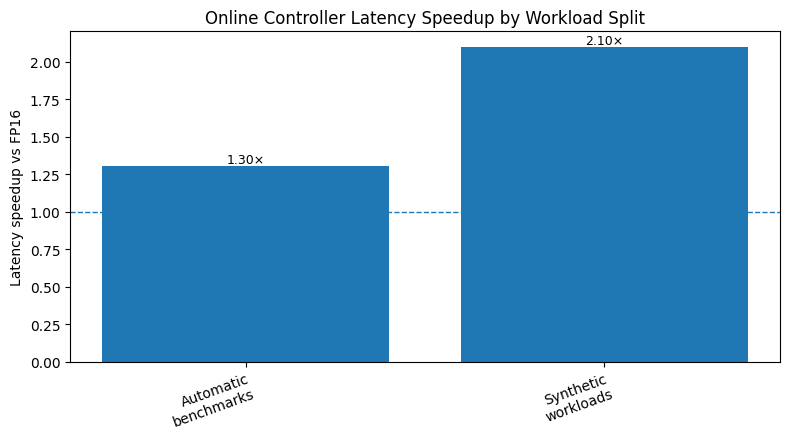

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/online_controller_highlight_figure_pack/online_split_energy_ratio_vs_fp16.png


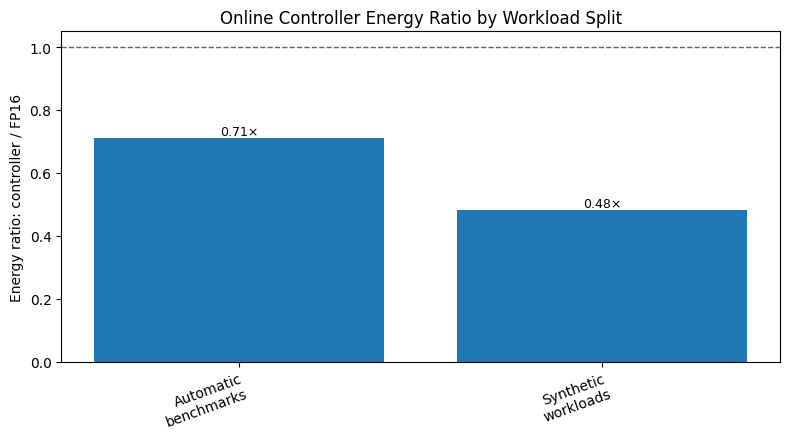

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/online_controller_highlight_figure_pack/online_split_controller_vs_fp16_latency_ms.png


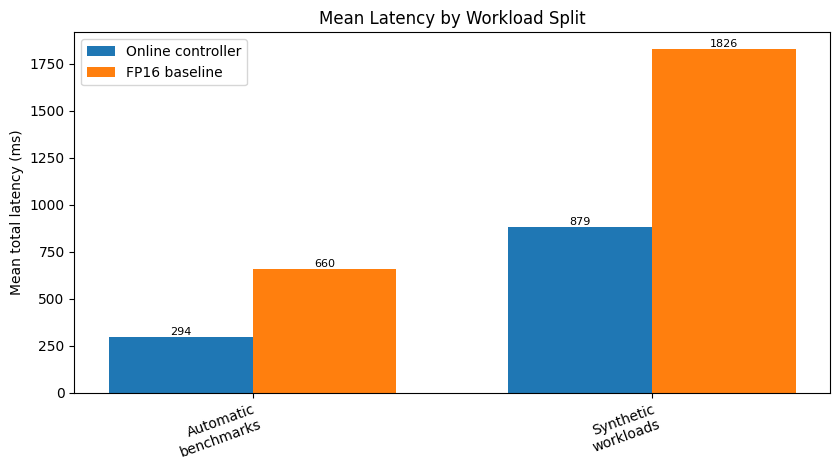

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/online_controller_highlight_figure_pack/online_controller_latency_speedup_vs_fp16_collapsed.png


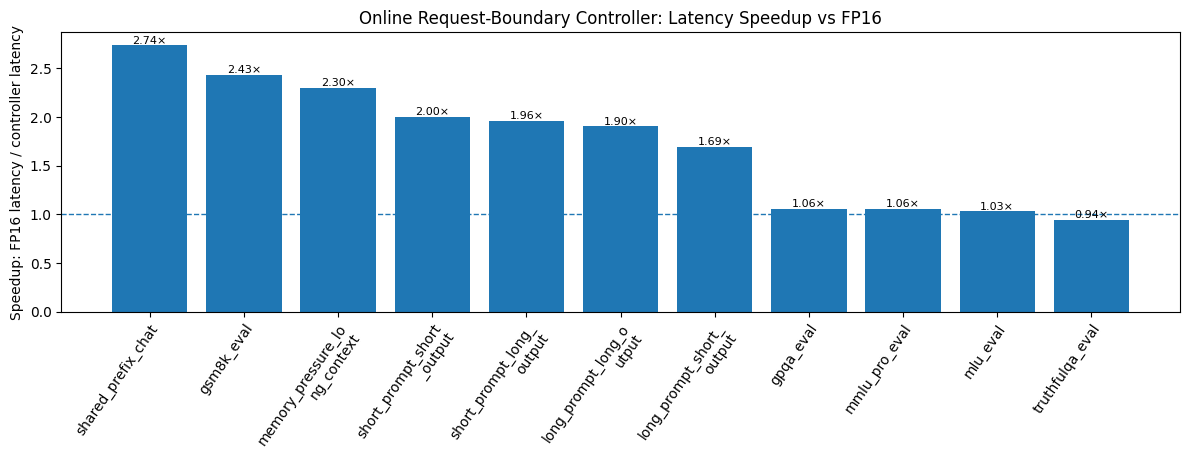

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/online_controller_highlight_figure_pack/online_controller_energy_ratio_vs_fp16_collapsed.png


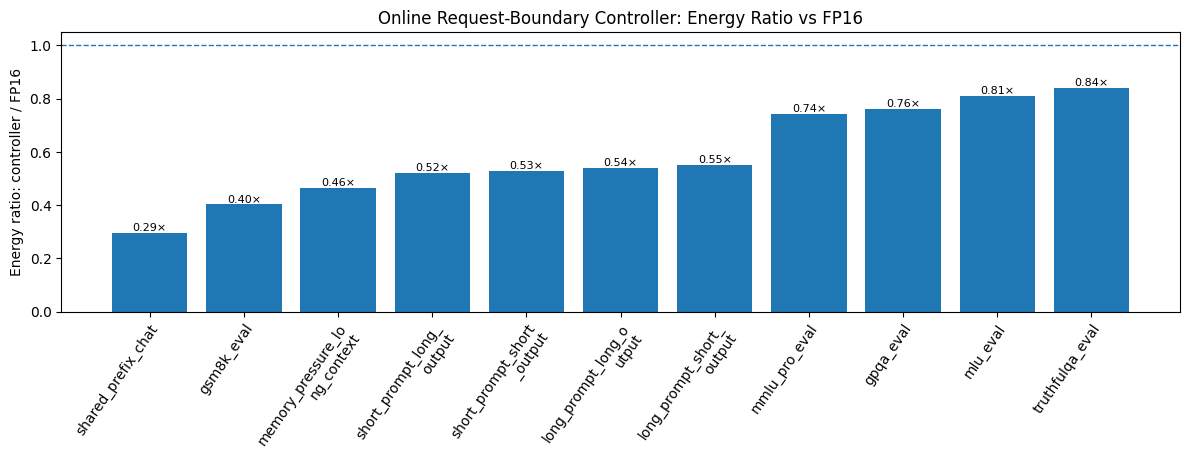

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/online_controller_highlight_figure_pack/online_controller_accuracy_delta_vs_fp16.png


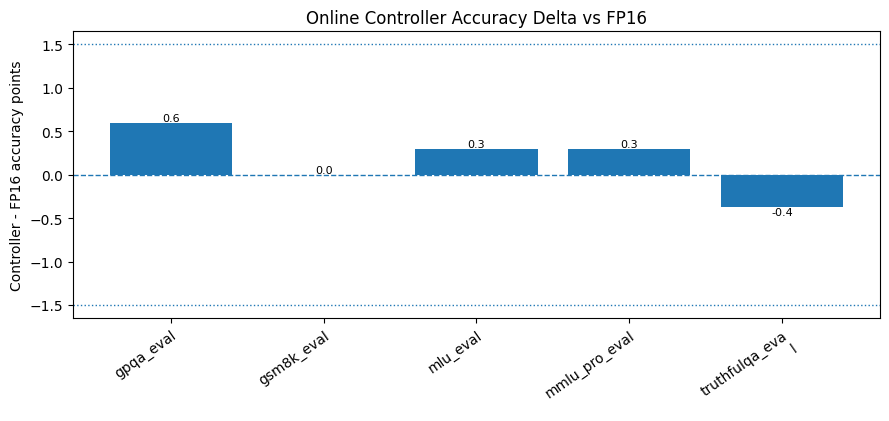

Skipping selected-mode figures: no online_controller_df or online_plan_df with selected modes found.
Skipping oracle figures: constraint_oracle_all_df is not available.
Online highlight figure directory: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/online_controller_highlight_figure_pack
Saved highlight figure index: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/learnable_controller_20260508_145059/online_controller_highlight_figure_pack/online_highlight_figure_index.csv


,figure_title,path,why_show,exists
0,Online split latency speedup vs FP16,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Shows that deployment-style synthetic workload...,True
1,Online split energy ratio vs FP16,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Shows energy reduction separately for automati...,True
2,Online split controller latency vs FP16 latency,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Shows the absolute latency reduction behind th...,True
3,Online controller latency speedup vs FP16 by w...,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Most direct per-workload result after collapsi...,True
4,Online controller energy ratio vs FP16 by work...,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Shows the strongest energy-efficiency claim wi...,True
5,Online controller accuracy delta vs FP16,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Supports the quality-gate claim on auto-graded...,True


In [11]:
# ============================================================
# Highlight figure pack AFTER online split summary tables
# ============================================================

import re
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

if "ONLINE_SPLIT_FINAL_TABLE_DIR" not in globals():
    raise RuntimeError("ONLINE_SPLIT_FINAL_TABLE_DIR is missing. Run the online split summary cell first.")

if "PLOT_DIR" not in globals():
    # Fallback if PLOT_DIR was not defined in this notebook.
    RESULTS_ROOT = ONLINE_SPLIT_FINAL_TABLE_DIR.parents[2]
    PLOT_DIR = RESULTS_ROOT / "plots" / "online_controller_split_highlights"

ONLINE_HIGHLIGHT_PLOT_DIR = PLOT_DIR / "online_controller_highlight_figure_pack"
ONLINE_HIGHLIGHT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

highlight_figure_rows = []


def register_highlight_figure(path, title, why_show):
    """
    Track saved highlight figures in a compact index table.
    """
    highlight_figure_rows.append({
        "figure_title": title,
        "path": str(path),
        "why_show": why_show,
        "exists": Path(path).exists(),
    })


def save_current_highlight_figure(filename, title, why_show):
    """
    Save current matplotlib figure and register it.
    """
    path = ONLINE_HIGHLIGHT_PLOT_DIR / filename
    plt.savefig(path, dpi=250, bbox_inches="tight")
    register_highlight_figure(path, title, why_show)
    print("Saved:", path)
    return path


def wrap_axis_labels(ax, labels, rotation=35, width=18):
    """
    Wrap long x-axis labels so they do not overlap or get cut off.
    """
    wrapped = [textwrap.fill(str(label), width=width) for label in labels]
    ax.set_xticklabels(
        wrapped,
        rotation=rotation,
        ha="right" if rotation != 0 else "center",
        rotation_mode="anchor",
    )


def collapse_workload_name_for_figures(workload_name):
    """
    Collapse benchmark examples and repeated synthetic variants.
    """
    workload_name = str(workload_name)

    if "__" in workload_name:
        workload_name = workload_name.split("__", 1)[0]

    if workload_name.startswith("shared_prefix_chat"):
        return "shared_prefix_chat"

    if workload_name.startswith("memory_pressure_long_context"):
        return "memory_pressure_long_context"

    return re.sub(r"_v\d+$", "", workload_name)


def average_online_compare_for_figures(df):
    """
    Collapse repeated workload variants before plotting.
    Keeps one bar per logical workload family.
    """
    out = df.copy()
    out["collapsed_workload_name"] = out["workload_name"].apply(
        collapse_workload_name_for_figures
    )

    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()

    collapsed = (
        out
        .groupby("collapsed_workload_name", as_index=False)[numeric_cols]
        .mean()
        .rename(columns={"collapsed_workload_name": "workload_name"})
    )

    return collapsed


def add_bar_labels(ax, values, fmt="{:.2f}", suffix="", y_offset=0.01):
    """
    Add labels above bars.
    """
    for i, value in enumerate(values):
        if pd.notna(value):
            ax.text(
                i,
                value + y_offset,
                fmt.format(value) + suffix,
                ha="center",
                va="bottom",
                fontsize=8,
            )


# ============================================================
# Figure 1: Online split latency speedup
# ============================================================

if "online_split_headline_summary_df" not in globals() or len(online_split_headline_summary_df) == 0:
    raise RuntimeError("online_split_headline_summary_df is missing or empty.")

split_plot_df = online_split_headline_summary_df.copy()

fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.arange(len(split_plot_df))
y = split_plot_df["mean_latency_speedup_with_routing"].values

ax.bar(x, y)
ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_title("Online Controller Latency Speedup by Workload Split")
ax.set_ylabel("Latency speedup vs FP16")
ax.set_xticks(x)
wrap_axis_labels(
    ax,
    split_plot_df["workload_split_label"].values,
    rotation=20,
    width=16,
)

for i, value in enumerate(y):
    if pd.notna(value):
        ax.text(i, value, f"{value:.2f}×", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
save_current_highlight_figure(
    filename="online_split_latency_speedup_vs_fp16.png",
    title="Online split latency speedup vs FP16",
    why_show="Shows that deployment-style synthetic workloads get the strongest latency gain.",
)
plt.show()


# ============================================================
# Figure 2: Online split energy ratio
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.arange(len(split_plot_df))
y = split_plot_df["mean_energy_ratio"].values

ax.bar(x, y)
ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_title("Online Controller Energy Ratio by Workload Split")
ax.set_ylabel("Energy ratio: controller / FP16")
ax.set_xticks(x)
wrap_axis_labels(
    ax,
    split_plot_df["workload_split_label"].values,
    rotation=20,
    width=16,
)

for i, value in enumerate(y):
    if pd.notna(value):
        ax.text(i, value, f"{value:.2f}×", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
save_current_highlight_figure(
    filename="online_split_energy_ratio_vs_fp16.png",
    title="Online split energy ratio vs FP16",
    why_show="Shows energy reduction separately for automatic benchmarks and synthetic workloads.",
)
plt.show()


# ============================================================
# Figure 3: Online split controller latency vs FP16 latency
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 4.8))

x = np.arange(len(split_plot_df))
width = 0.36

controller_latency = split_plot_df["mean_controller_total_latency_with_routing_ms"].values
fp16_latency = split_plot_df["mean_fp16_total_latency_ms"].values

ax.bar(x - width / 2, controller_latency, width, label="Online controller")
ax.bar(x + width / 2, fp16_latency, width, label="FP16 baseline")

ax.set_title("Mean Latency by Workload Split")
ax.set_ylabel("Mean total latency (ms)")
ax.set_xticks(x)
wrap_axis_labels(
    ax,
    split_plot_df["workload_split_label"].values,
    rotation=20,
    width=16,
)
ax.legend()

for i, value in enumerate(controller_latency):
    if pd.notna(value):
        ax.text(i - width / 2, value, f"{value:.0f}", ha="center", va="bottom", fontsize=8)

for i, value in enumerate(fp16_latency):
    if pd.notna(value):
        ax.text(i + width / 2, value, f"{value:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
save_current_highlight_figure(
    filename="online_split_controller_vs_fp16_latency_ms.png",
    title="Online split controller latency vs FP16 latency",
    why_show="Shows the absolute latency reduction behind the speedup numbers.",
)
plt.show()


# ============================================================
# Figure 4: Per-workload online latency speedup vs FP16
# ============================================================

if "online_compare_df" not in globals() or len(online_compare_df) == 0:
    raise RuntimeError("online_compare_df is missing or empty.")

online_workload_plot_df = average_online_compare_for_figures(online_compare_df)

online_workload_plot_df = online_workload_plot_df.sort_values(
    "latency_speedup_with_routing",
    ascending=False,
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4.8))

x = np.arange(len(online_workload_plot_df))
y = online_workload_plot_df["latency_speedup_with_routing"].values

ax.bar(x, y)
ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_title("Online Request-Boundary Controller: Latency Speedup vs FP16")
ax.set_ylabel("Speedup: FP16 latency / controller latency")
ax.set_xticks(x)
wrap_axis_labels(
    ax,
    online_workload_plot_df["workload_name"].values,
    rotation=55,
    width=18,
)

for i, value in enumerate(y):
    if pd.notna(value):
        ax.text(i, value, f"{value:.2f}×", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.subplots_adjust(bottom=0.34)
save_current_highlight_figure(
    filename="online_controller_latency_speedup_vs_fp16_collapsed.png",
    title="Online controller latency speedup vs FP16 by workload",
    why_show="Most direct per-workload result after collapsing repeated synthetic variants.",
)
plt.show()


# ============================================================
# Figure 5: Per-workload online energy ratio vs FP16
# ============================================================

online_energy_plot_df = online_workload_plot_df.sort_values(
    "energy_ratio",
    ascending=True,
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4.8))

x = np.arange(len(online_energy_plot_df))
y = online_energy_plot_df["energy_ratio"].values

ax.bar(x, y)
ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_title("Online Request-Boundary Controller: Energy Ratio vs FP16")
ax.set_ylabel("Energy ratio: controller / FP16")
ax.set_xticks(x)
wrap_axis_labels(
    ax,
    online_energy_plot_df["workload_name"].values,
    rotation=55,
    width=18,
)

for i, value in enumerate(y):
    if pd.notna(value):
        ax.text(i, value, f"{value:.2f}×", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.subplots_adjust(bottom=0.34)
save_current_highlight_figure(
    filename="online_controller_energy_ratio_vs_fp16_collapsed.png",
    title="Online controller energy ratio vs FP16 by workload",
    why_show="Shows the strongest energy-efficiency claim without claiming memory savings.",
)
plt.show()


# ============================================================
# Figure 6: Automatic benchmark accuracy delta
# ============================================================

if "online_controller_accuracy_df" in globals() and len(online_controller_accuracy_df) > 0:
    accuracy_plot_df = online_controller_accuracy_df.copy()

    if "workload_name" in accuracy_plot_df.columns:
        accuracy_plot_df["workload_name"] = accuracy_plot_df["workload_name"].apply(
            collapse_workload_name_for_figures
        )

    accuracy_plot_df = accuracy_plot_df.sort_values("workload_name").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 4.5))

    x = np.arange(len(accuracy_plot_df))
    y = accuracy_plot_df["delta_pts"].values

    ax.bar(x, y)
    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.axhline(1.5, linestyle=":", linewidth=1)
    ax.axhline(-1.5, linestyle=":", linewidth=1)
    ax.set_title("Online Controller Accuracy Delta vs FP16")
    ax.set_ylabel("Controller - FP16 accuracy points")
    ax.set_xticks(x)
    wrap_axis_labels(
        ax,
        accuracy_plot_df["workload_name"].values,
        rotation=35,
        width=14,
    )

    for i, value in enumerate(y):
        if pd.notna(value):
            ax.text(
                i,
                value,
                f"{value:.1f}",
                ha="center",
                va="bottom" if value >= 0 else "top",
                fontsize=8,
            )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)
    save_current_highlight_figure(
        filename="online_controller_accuracy_delta_vs_fp16.png",
        title="Online controller accuracy delta vs FP16",
        why_show="Supports the quality-gate claim on auto-graded benchmarks.",
    )
    plt.show()
else:
    print("Skipping accuracy-delta figure: online_controller_accuracy_df is missing or empty.")


# ============================================================
# Figure 7: Controller selected-mode counts
# ============================================================

mode_count_df = pd.DataFrame()
weighted_mode_df = pd.DataFrame()

# Prefer raw online-controller rows if available because they preserve delegated mode.
if "online_controller_df" in globals() and len(online_controller_df) > 0 and "controller_selected_mode_name" in online_controller_df.columns:
    route_df = online_controller_df.copy()

    if "success" in route_df.columns:
        route_df = route_df[route_df["success"] == True].copy()

    route_df["base_workload_name"] = route_df["workload_name"].apply(
        collapse_workload_name_for_figures
    )
    route_df["selected_mode"] = route_df["controller_selected_mode_name"]

elif "online_plan_df" in globals() and len(online_plan_df) > 0 and "selected_mode_name" in online_plan_df.columns:
    route_df = online_plan_df.copy()
    route_df["base_workload_name"] = route_df["workload_name"].apply(
        collapse_workload_name_for_figures
    )
    route_df["selected_mode"] = route_df["selected_mode_name"]

else:
    route_df = pd.DataFrame()

if len(route_df) > 0:
    mode_count_df = (
        route_df["selected_mode"]
        .value_counts()
        .rename_axis("selected_mode")
        .reset_index(name="num_routes")
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))

    x = np.arange(len(mode_count_df))
    y = mode_count_df["num_routes"].values

    ax.bar(x, y)
    ax.set_title("Controller Selected-Mode Counts")
    ax.set_ylabel("Number of routed examples")
    ax.set_xticks(x)
    wrap_axis_labels(
        ax,
        mode_count_df["selected_mode"].values,
        rotation=30,
        width=18,
    )

    for i, value in enumerate(y):
        ax.text(i, value, str(value), ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)
    save_current_highlight_figure(
        filename="online_controller_selected_mode_counts_raw.png",
        title="Online controller selected-mode counts",
        why_show="Shows that routing no longer collapses everything to one mode.",
    )
    plt.show()

    # One vote per workload family.
    weighted_rows = []

    for workload_family, group in route_df.groupby("base_workload_name"):
        selected_mode = group["selected_mode"].mode().iloc[0]
        weighted_rows.append({
            "workload_family": workload_family,
            "selected_mode": selected_mode,
            "raw_rows": len(group),
        })

    weighted_mode_df = pd.DataFrame(weighted_rows).sort_values("workload_family")

    weighted_counts_df = (
        weighted_mode_df["selected_mode"]
        .value_counts()
        .rename_axis("selected_mode")
        .reset_index(name="num_workload_families")
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))

    x = np.arange(len(weighted_counts_df))
    y = weighted_counts_df["num_workload_families"].values

    ax.bar(x, y)
    ax.set_title("Controller Mode Selection\nOne Vote per Workload Family")
    ax.set_ylabel("Number of workload families")
    ax.set_xticks(x)
    wrap_axis_labels(
        ax,
        weighted_counts_df["selected_mode"].values,
        rotation=30,
        width=18,
    )

    for i, value in enumerate(y):
        ax.text(i, value, str(value), ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)
    save_current_highlight_figure(
        filename="online_controller_mode_selection_one_vote_per_family.png",
        title="Online controller mode selection, one vote per workload family",
        why_show="Cleaner interpretability figure that prevents large benchmark sample counts from dominating.",
    )
    plt.show()

    display(weighted_mode_df)

else:
    print("Skipping selected-mode figures: no online_controller_df or online_plan_df with selected modes found.")


# ============================================================
# Figure 8: Optional constraint-aware oracle comparison
# ============================================================

if "constraint_oracle_all_df" in globals() and len(constraint_oracle_all_df) > 0:
    oracle_plot_df = constraint_oracle_all_df.copy()

    if "order" in oracle_plot_df.columns:
        oracle_plot_df = oracle_plot_df.sort_values("order").reset_index(drop=True)

    # Latency comparison.
    fig, ax = plt.subplots(figsize=(13, 5.2))

    x = np.arange(len(oracle_plot_df))
    width = 0.36

    online_y = oracle_plot_df["online_speedup_vs_fp16"].values
    oracle_y = oracle_plot_df["constraint_oracle_speedup_vs_fp16"].values

    ax.bar(x - width / 2, online_y, width, label="Online controller")
    ax.bar(x + width / 2, oracle_y, width, label="Constraint-aware oracle")
    ax.axhline(1.0, linestyle="--", linewidth=1)

    ax.set_title("Online Controller vs Constraint-Aware Oracle")
    ax.set_ylabel("Latency speedup vs FP16")
    ax.set_xticks(x)
    wrap_axis_labels(
        ax,
        oracle_plot_df["workload_name"].values,
        rotation=40,
        width=18,
    )
    ax.legend()

    for i, value in enumerate(online_y):
        if pd.notna(value):
            ax.text(i - width / 2, value, f"{value:.2f}×", ha="center", va="bottom", fontsize=8)

    for i, value in enumerate(oracle_y):
        if pd.notna(value):
            ax.text(i + width / 2, value, f"{value:.2f}×", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.30)
    save_current_highlight_figure(
        filename="online_controller_vs_constraint_oracle_latency.png",
        title="Online controller vs constraint-aware oracle latency",
        why_show="Important caveat figure showing the controller is strong but not oracle-optimal.",
    )
    plt.show()

    # Energy comparison.
    fig, ax = plt.subplots(figsize=(13, 5.2))

    online_y = oracle_plot_df["online_energy_reduction_pct"].values
    oracle_y = oracle_plot_df["constraint_oracle_energy_reduction_pct"].values

    ax.bar(x - width / 2, online_y, width, label="Online controller")
    ax.bar(x + width / 2, oracle_y, width, label="Constraint-aware oracle")
    ax.axhline(0.0, linestyle="--", linewidth=1)

    ax.set_title("Energy Reduction vs FP16")
    ax.set_ylabel("Energy reduction (%)")
    ax.set_xticks(x)
    wrap_axis_labels(
        ax,
        oracle_plot_df["workload_name"].values,
        rotation=40,
        width=18,
    )
    ax.legend()

    for i, value in enumerate(online_y):
        if pd.notna(value):
            ax.text(i - width / 2, value, f"{value:.0f}%", ha="center", va="bottom", fontsize=8)

    for i, value in enumerate(oracle_y):
        if pd.notna(value):
            ax.text(i + width / 2, value, f"{value:.0f}%", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.30)
    save_current_highlight_figure(
        filename="online_controller_vs_constraint_oracle_energy.png",
        title="Online controller vs constraint-aware oracle energy",
        why_show="Shows that controller energy savings are close to the constraint-aware oracle on average.",
    )
    plt.show()

else:
    print("Skipping oracle figures: constraint_oracle_all_df is not available.")


# ============================================================
# Register already-saved heatmaps if they exist
# ============================================================

existing_highlight_candidates = [
    (
        PLOT_DIR / "latency_speedup_vs_baseline_heatmap.png",
        "Fixed-mode latency speedup heatmap",
        "Shows which fixed modes dominate different workload families.",
    ),
    (
        PLOT_DIR / "energy_ratio_vs_baseline_heatmap.png",
        "Fixed-mode energy ratio heatmap",
        "Shows energy-efficiency patterns across fixed modes.",
    ),
    (
        PLOT_DIR / "automatic_accuracy_heatmap.png",
        "Automatic benchmark accuracy heatmap",
        "Shows benchmark quality across auto-graded tasks.",
    ),
    (
        PLOT_DIR / "throughput_heatmap.png",
        "Throughput heatmap",
        "Highlights the throughput advantage of batching-related modes.",
    ),
    (
        PLOT_DIR / "prefill_share_heatmap.png",
        "Prefill share heatmap",
        "Explains why some workloads favor prefill/prefix-oriented modes.",
    ),
    (
        PLOT_DIR / "decode_share_heatmap.png",
        "Decode share heatmap",
        "Explains why long-generation workloads favor decode-oriented modes.",
    ),
    (
        PLOT_DIR / "peak_gpu_memory_heatmap.png",
        "Peak GPU memory heatmap",
        "Useful caveat: memory is approximately unchanged.",
    ),
]

for path, title, why_show in existing_highlight_candidates:
    if Path(path).exists():
        register_highlight_figure(path, title, why_show)


# ============================================================
# Save final highlight index
# ============================================================

highlight_figure_df = pd.DataFrame(highlight_figure_rows)
highlight_figure_df = highlight_figure_df.drop_duplicates(subset=["path"]).reset_index(drop=True)

highlight_table_path = ONLINE_HIGHLIGHT_PLOT_DIR / "online_highlight_figure_index.csv"
highlight_figure_df.to_csv(highlight_table_path, index=False)

print("Online highlight figure directory:", ONLINE_HIGHLIGHT_PLOT_DIR)
print("Saved highlight figure index:", highlight_table_path)

display(highlight_figure_df)